# Datapost religion and tolerance plots

This notebook recreates only the plots from `religion.ipynb` that appear in `/Users/chapin.lenthall-cleary/Downloads/Datapost 5_19 religion and tolerance.pdf`.

Outputs generated:
- `diamond_left_vs_right_avg_by_religion_everyone_labeled.png`
- `diamond_scatter_left_vs_right_avg_by_ideology_gender_protestant.png`
- `diamond_vectors_prot_minus_nonprot_by_ideology_Men_2025.png`
- `diamond_vectors_prot_minus_nonprot_by_ideology_Women_2025.png`
- `diamond_left_vs_right_avg_by_religion_everyone_gender_ideo_controlled_labeled.png`
- `diamond_heatmap_left_vs_right_by_gender_protestant.png`
- `stacked_bar_religious_attendance_by_religion.png`
- `diamond_left_vs_right_avg_by_religion_everyone_raw_conservative_schoollean_nonnegative_labeled.png`


Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


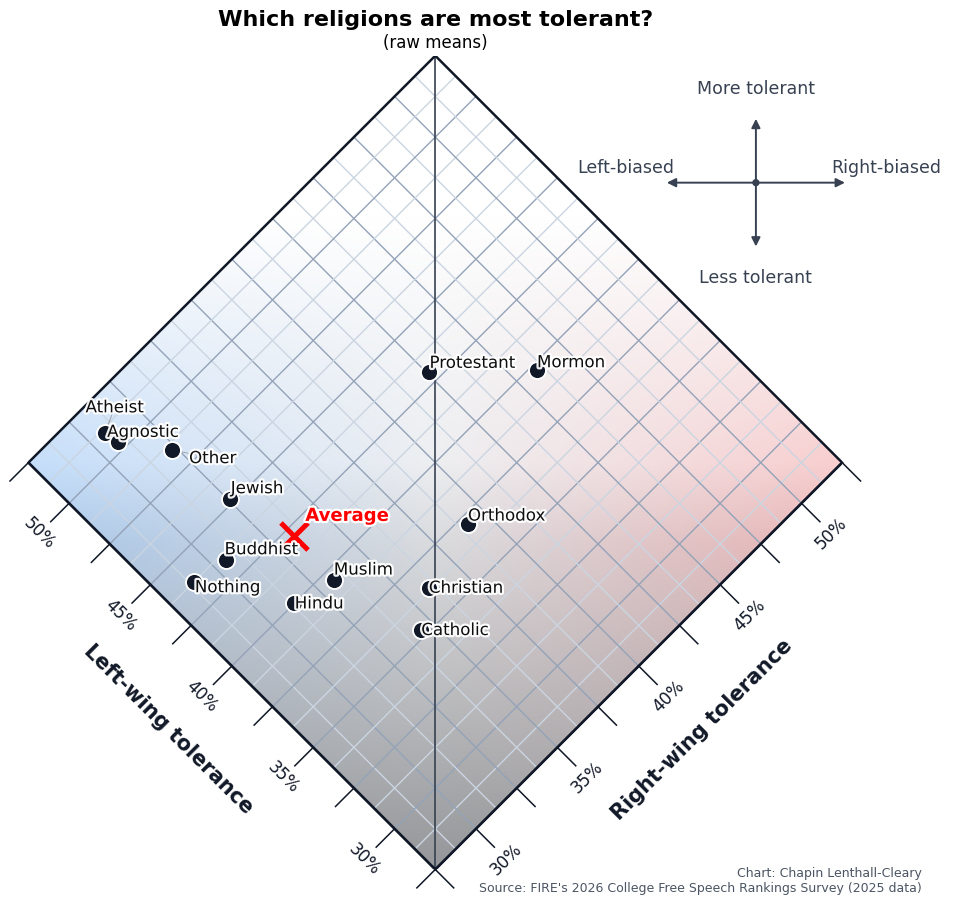

Saved: /Users/chapin.lenthall-cleary/diamond_left_vs_right_avg_by_religion_everyone_labeled.png
Diamond tick range (Everyone, with labels): 26.9% to 52.9%

Point readout (Everyone; with labels):
  Religion Symbol Left avg Right avg     N
Protestant      +    43.0%     42.6%  4096
  Catholic      C    35.0%     34.1% 12634
    Mormon    LDS    39.6%     46.1%   553
  Orthodox     OC    36.9%     39.0%  1067
    Jewish      ✡    45.3%     32.2%  2560
    Muslim      ☪    39.4%     32.9%  2268
   Atheist      A    51.4%     30.3%  7862
  Agnostic      ?    50.7%     30.4%  9688
   Nothing      ∅    43.8%     28.4%  8978
 Christian      ✚    36.1%     35.7% 13285
  Buddhist      ☸    43.5%     30.1%  1006
     Hindu     OM    39.9%     30.9%  3077
     Other      *    48.7%     31.9%   262


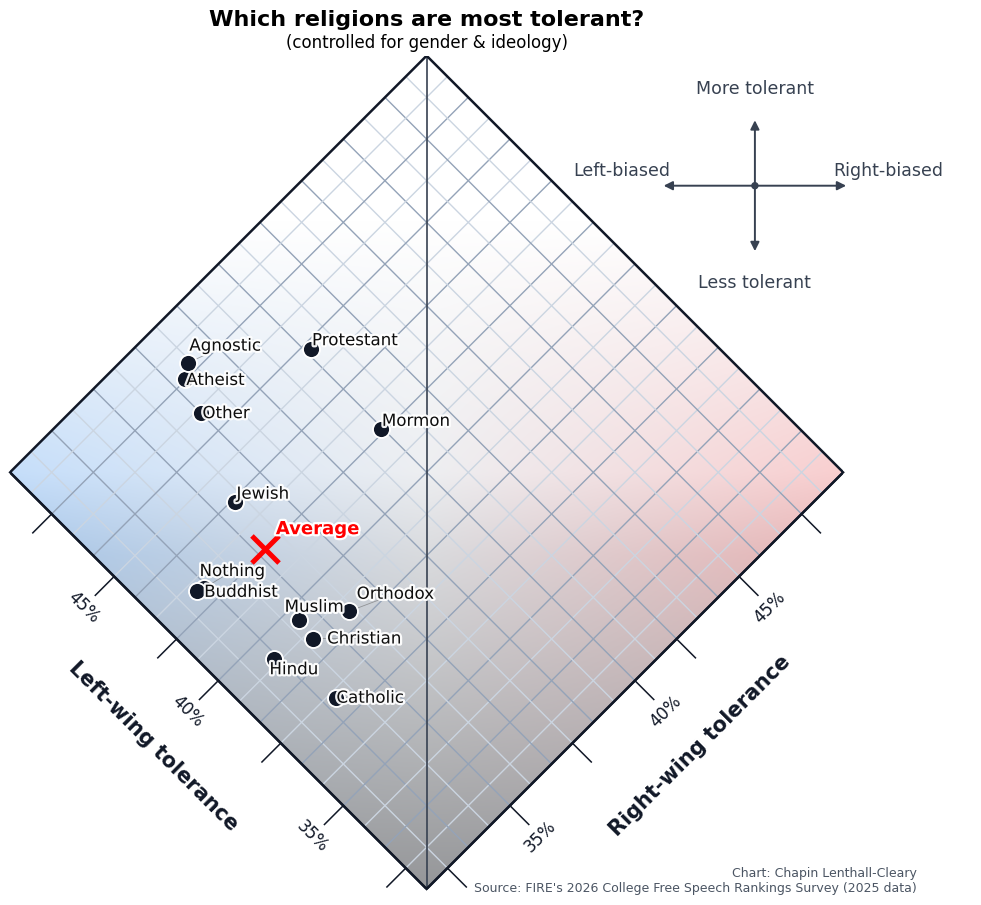

Saved: /Users/chapin.lenthall-cleary/diamond_left_vs_right_avg_by_religion_everyone_gender_ideo_controlled_labeled.png
Diamond tick range (Everyone, with labels): 31.3% to 49.6%

Point readout (Everyone; with labels):
  Religion Symbol Left avg Right avg     N
Protestant      +    45.7%     40.6%  3974
  Catholic      C    37.5%     33.5% 12392
    Mormon    LDS    42.4%     40.4%   457
  Orthodox     OC    39.1%     35.7%  1013
    Jewish      ✡    44.0%     35.6%  2412
    Muslim      ☪    40.0%     34.4%  2202
   Atheist      A    47.8%     37.2%  7311
  Agnostic      ?    48.1%     37.6%  9006
   Nothing      ∅    42.8%     33.0%  8277
 Christian      ✚    39.3%     34.3% 13014
  Buddhist      ☸    42.9%     32.8%   930
     Hindu     OM    39.7%     33.0%  3011
     Other      *    46.7%     36.8%   199


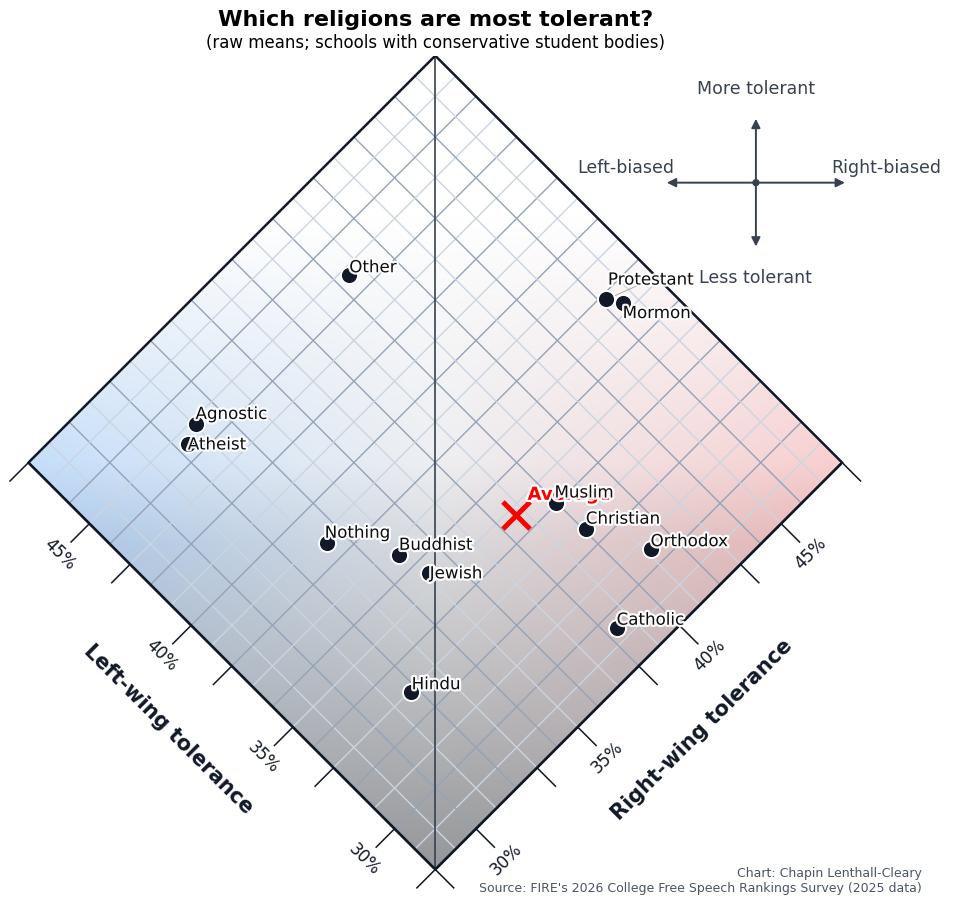

Saved: /Users/chapin.lenthall-cleary/diamond_left_vs_right_avg_by_religion_everyone_raw_conservative_schoollean_nonnegative_labeled.png
Diamond tick range (Everyone, with labels): 27.5% to 47.7%

Point readout (Everyone; with labels):
  Religion Symbol Left avg Right avg    N
Protestant      +    37.4%     45.9%  798
  Catholic      C    29.0%     38.0% 2122
    Mormon    LDS    36.9%     46.2%  277
  Orthodox     OC    30.1%     40.8%  129
    Jewish      ✡    35.0%     34.7%  106
    Muslim      ☪    33.6%     39.6%   91
   Atheist      A    44.2%     31.9%  443
  Agnostic      ?    44.5%     32.6%  704
   Nothing      ∅    38.3%     32.9%  717
 Christian      ✚    32.2%     39.7% 2859
  Buddhist      ☸    36.2%     34.4%   31
     Hindu     OM    32.5%     31.3%  107
     Other      *    44.4%     40.1%   18


In [1]:
#!/usr/bin/env python3
"""
Diamond scatter of average tolerance for Left- vs Right-wing speakers,
with one point per religion.

Outputs eight plots:
  1. Everyone, raw, with labels
  2. Men, raw, with labels
  3. Women, raw, with labels
  4. Everyone, raw, symbols only + legend
  5. Men, raw, symbols only + legend
  6. Women, raw, symbols only + legend
  7. Everyone, controlled for gender + ideology, with labels
  8. Everyone, controlled for gender + ideology, symbols only + legend
  9. Everyone, controlled for gender + ideology + school leaning, with labels
 10. Everyone, controlled for gender + ideology + school leaning, symbols only + legend
 11. Everyone, controlled for religious attendance, with labels
 12. Everyone, controlled for religious attendance, symbols only + legend
 13. Everyone, controlled for attendance + ideology + gender, with labels
 14. Everyone, controlled for attendance + ideology + gender, symbols only + legend
 15. Everyone, raw means among students at conservative-leaning schools, with labels
 16. Everyone, raw means among students at conservative-leaning schools, symbols only + legend
"""

from pathlib import Path
from typing import Callable, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

from matplotlib.colors import to_rgb
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch, Circle, Polygon, Rectangle

try:
    from adjustText import adjust_text
    HAS_ADJUSTTEXT = True
except ImportError:
    HAS_ADJUSTTEXT = False


# =========================
# Config
# =========================
CSV_PATH = Path("cfsrALL_24_25.csv")
YEAR = 2025

FIG_W, FIG_H = 8.8 * 1.3, 8.6 * 1.3
LABEL_FONTSIZE = 12.0
SYMBOL_FONTSIZE = 22.0
AVG_MARKER_SIZE = 380
LABEL_ALPHA = 0.94

BUFFER_PP_MIN = 1.5
BUFFER_FRAC = 0.06

CREDIT_TEXT = (
    "Chart: Chapin Lenthall-Cleary\n"
    "Source: FIRE's 2026 College Free Speech Rankings Survey (2025 data)"
)
SUPTITLE_Y = 0.900
TITLE_PAD = 6
CREDIT_X, CREDIT_Y = 0.876, 0.108
CREDIT_COLOR = "#4b5563"

COMPASS_W = 0.40
COMPASS_H = 0.30
COMPASS_PAD = 0.006
COMPASS_SHIFT_RIGHT = 0.10

RELIGION_LABELS = {
    1: "Protestant",
    2: "Catholic",
    3: "Mormon",
    4: "Orthodox",
    5: "Jewish",
    6: "Muslim",
    7: "Atheist",
    8: "Agnostic",
    9: "Nothing",
    10: "Christian",
    11: "Buddhist",
    12: "Hindu",
    13: "Other",
}

RELIGION_SYMBOLS = {
    1: "+",   # Protestant
    2: "C",   # Catholic
    3: "LDS", # Mormon
    4: "OC",  # Orthodox Christian
    5: "✡",   # Jewish
    6: "☪",   # Muslim
    7: "A",   # Atheist
    8: "?",   # Agnostic
    9: "∅",   # Nothing in particular
    10: "✚",  # Christian
    11: "☸",  # Buddhist
    12: "OM",  # Hindu
    13: "*",   # Other
}

POPULATIONS = [
    {"key": "everyone", "label": "Everyone", "gender_code": None},
    {"key": "men", "label": "Men", "gender_code": 1},
    {"key": "women", "label": "Women", "gender_code": 2},
]
POPULATION_TITLE_LABELS = {
    "Everyone": "college students",
    "Men": "male college students",
    "Women": "female college students",
}

IDEO_COL = "ideo"
SCHOOL_COL = "schoolname"
ATTEND_COL = "attendreligserv"
IDEO_KEEP = set(range(1, 12))
ATTEND_KEEP = set(range(1, 10))
LEANING_WEIGHTS = {
    1: 3,   # Very liberal
    2: 2,   # Somewhat liberal
    3: 1,   # Slightly liberal
    4: 0,   # Moderate
    5: -1,  # Slightly conservative
    6: -2,  # Somewhat conservative
    7: -3,  # Very conservative
    8: 3,   # Democratic Socialist
    9: 0,   # Libertarian
}
CONSERVATIVE_POSITIVE_LEANING_WEIGHTS = {code: -weight for code, weight in LEANING_WEIGHTS.items()}

RIGHT_TRIAD = ["spk_abortion", "spk_trans", "spk_blm"]
LEFT_TRIAD = ["spk_cathped", "spk_policekkk", "spk_kidtrans"]
SPK_ALL = RIGHT_TRIAD + LEFT_TRIAD


# =========================
# Helpers: scoring + data
# =========================
def scale_triad_to_pct(sum_vals: pd.Series, k: int = 3) -> pd.Series:
    """Maps triad sum (k..4k) to 0..100%."""
    return (sum_vals - k) / (3 * k) * 100.0


def load_religion_data(csv_path: Path, year: int) -> pd.DataFrame:
    df = pd.read_csv(csv_path, low_memory=False)
    required = ["datayear", "gender_bin", IDEO_COL, SCHOOL_COL, ATTEND_COL, "religion", *SPK_ALL]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    for col in ["datayear", "gender_bin", IDEO_COL, ATTEND_COL, "religion", *SPK_ALL]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df[SCHOOL_COL] = df[SCHOOL_COL].astype("string").str.strip()

    df = df[(df["datayear"] == year) & (df["religion"].isin(range(1, 14)))].copy()
    if df.empty:
        raise SystemExit(f"No rows found for datayear == {year} and religion in 1..13.")

    in_range = df[SPK_ALL].ge(1) & df[SPK_ALL].le(4)
    df = df[in_range.all(axis=1)].copy()
    if df.empty:
        raise SystemExit("No rows remain after requiring all six spk_* columns to be in [1,4].")

    return df


def add_lr_scores(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["right_sum"] = df[RIGHT_TRIAD].sum(axis=1).astype(int)
    df["left_sum"] = df[LEFT_TRIAD].sum(axis=1).astype(int)
    df["right_pct"] = scale_triad_to_pct(df["right_sum"], k=len(RIGHT_TRIAD))
    df["left_pct"] = scale_triad_to_pct(df["left_sum"], k=len(LEFT_TRIAD))
    return df


def finalize_religion_stats(stats: pd.DataFrame) -> pd.DataFrame:
    if stats.empty:
        raise SystemExit("No religion groups to plot after filtering; check data/filtering.")

    stats = stats.copy()
    stats["religion"] = stats["religion"].astype(int)
    stats["Religion"] = stats["religion"].map(RELIGION_LABELS)
    stats["symbol"] = stats["religion"].map(RELIGION_SYMBOLS)
    stats["left_avg"] = pd.to_numeric(stats["left_avg"], errors="coerce").round(1)
    stats["right_avg"] = pd.to_numeric(stats["right_avg"], errors="coerce").round(1)
    return stats.sort_values("religion").reset_index(drop=True)


def compute_religion_stats(df: pd.DataFrame, *, gender_code: Optional[int]) -> pd.DataFrame:
    df = df.copy()
    if gender_code is not None:
        df = df[df["gender_bin"] == gender_code].copy()
        if df.empty:
            raise SystemExit(f"No rows remain after filtering to gender_bin == {gender_code}.")

    df = add_lr_scores(df)
    stats = (
        df.groupby("religion", dropna=True)
        .agg(
            left_avg=("left_pct", "mean"),
            right_avg=("right_pct", "mean"),
            n=("left_pct", "size"),
        )
        .reset_index()
    )
    return finalize_religion_stats(stats)


def residualize_categorical_fe(
    df: pd.DataFrame,
    value_cols: list[str],
    *,
    fe_col: str,
    suffix: str = "_adj",
    clip_0_100: bool = True,
) -> pd.DataFrame:
    """One-way fixed effect: y_adj = y - mean(y | fe_col) + mean(y)."""
    df = df.copy()
    if fe_col not in df.columns:
        raise ValueError(f"Missing fixed-effect column '{fe_col}'.")

    for col in value_cols:
        y = pd.to_numeric(df[col], errors="coerce")
        overall_mean = float(np.nanmean(y))
        means_by_group = (
            pd.DataFrame({fe_col: df[fe_col], col: y})
            .dropna(subset=[fe_col, col])
            .groupby(fe_col)[col]
            .mean()
        )
        adj = y - df[fe_col].map(means_by_group) + overall_mean
        if clip_0_100:
            adj = np.clip(adj, 0, 100)
        df[col + suffix] = pd.to_numeric(adj, errors="coerce").round(1)
    return df


def residualize_categorical_controls(
    df: pd.DataFrame,
    value_cols: list[str],
    *,
    cat_cols: list[str],
    suffix: str = "_catadj",
    clip_0_100: bool = True,
) -> pd.DataFrame:
    """Residualize outcomes on multiple categorical fixed effects, then add back each outcome mean."""
    df = df.copy()
    missing = [c for c in cat_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing categorical control columns: {missing}")

    X_parts = [pd.Series(1.0, index=df.index, name="intercept")]
    valid_controls = pd.Series(True, index=df.index)
    for cat_col in cat_cols:
        cat = pd.to_numeric(df[cat_col], errors="coerce")
        valid_controls &= cat.notna()
        dummies = pd.get_dummies(cat.astype("Int64"), prefix=cat_col, dummy_na=False).astype(float)
        X_parts.append(dummies)
    X_base = pd.concat(X_parts, axis=1)

    for col in value_cols:
        y = pd.to_numeric(df[col], errors="coerce")
        valid = valid_controls & y.notna()
        if valid.sum() == 0:
            df[col + suffix] = np.nan
            continue

        X = X_base.loc[valid].to_numpy(dtype=float)
        yv = y.loc[valid].to_numpy(dtype=float)
        beta, *_ = np.linalg.lstsq(X, yv, rcond=None)
        fitted = X @ beta
        adj_valid = yv - (fitted - float(np.nanmean(yv)))

        adj = pd.Series(np.nan, index=df.index, dtype=float)
        adj.loc[valid] = adj_valid
        if clip_0_100:
            adj = np.clip(adj, 0, 100)
        df[col + suffix] = pd.to_numeric(adj, errors="coerce").round(1)
    return df


def compute_school_leaning_scores(
    df: pd.DataFrame,
    *,
    weights: dict[int, int] = LEANING_WEIGHTS,
    score_col: str = "leaning_score",
    n_col: str = "leaning_n",
) -> pd.DataFrame:
    """Compute school leaning scores using the talk.ipynb ideology weighting."""
    work = df.copy()
    work[IDEO_COL] = pd.to_numeric(work[IDEO_COL], errors="coerce")
    work[SCHOOL_COL] = work[SCHOOL_COL].astype("string").str.strip()

    valid = work[IDEO_COL].isin(list(weights.keys())) & work[SCHOOL_COL].notna() & (work[SCHOOL_COL] != "")
    lean_base = work.loc[valid, [SCHOOL_COL, IDEO_COL]].copy()
    if lean_base.empty:
        raise ValueError("No valid ideology responses to compute school leaning scores.")

    lean_base["leaning_weight"] = lean_base[IDEO_COL].map(weights).fillna(0)
    leanings = (
        lean_base.groupby(SCHOOL_COL, dropna=True)
        .agg(
            **{
                score_col: ("leaning_weight", "mean"),
                n_col: (IDEO_COL, "size"),
            }
        )
        .reset_index()
    )
    return leanings


def residualize_ideo_and_school_leaning(
    df: pd.DataFrame,
    value_cols: list[str],
    *,
    suffix: str = "_ideo_schoollean_adj",
    clip_0_100: bool = True,
) -> pd.DataFrame:
    """
    Residualize respondent-level outcomes on ideology fixed effects plus a
    linear school-leaning score, then add back the outcome grand mean.
    """
    df = df.copy()
    required = [IDEO_COL, "leaning_score"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required control columns: {missing}")

    ideo_dummies = pd.get_dummies(df[IDEO_COL].astype("Int64"), prefix="ideo", dummy_na=False)
    lean = pd.to_numeric(df["leaning_score"], errors="coerce")
    lean_centered = lean - lean.mean(skipna=True)

    X_base = pd.concat(
        [pd.Series(1.0, index=df.index, name="intercept"), ideo_dummies.astype(float), lean_centered.rename("school_leaning_centered")],
        axis=1,
    )

    for col in value_cols:
        y = pd.to_numeric(df[col], errors="coerce")
        valid = y.notna() & lean_centered.notna()
        if valid.sum() == 0:
            df[col + suffix] = np.nan
            continue

        X = X_base.loc[valid].to_numpy(dtype=float)
        yv = y.loc[valid].to_numpy(dtype=float)
        beta, *_ = np.linalg.lstsq(X, yv, rcond=None)
        fitted = X @ beta
        adj_valid = yv - (fitted - float(np.nanmean(yv)))

        adj = pd.Series(np.nan, index=df.index, dtype=float)
        adj.loc[valid] = adj_valid
        if clip_0_100:
            adj = np.clip(adj, 0, 100)
        df[col + suffix] = pd.to_numeric(adj, errors="coerce").round(1)
    return df


def _gender_balanced_religion_stats(df: pd.DataFrame, left_col: str, right_col: str) -> pd.DataFrame:
    by_gender = (
        df.groupby(["religion", "gender_bin"], dropna=True)
        .agg(
            left_avg=(left_col, "mean"),
            right_avg=(right_col, "mean"),
            n=(left_col, "size"),
        )
        .reset_index()
    )

    left_wide = by_gender.pivot(index="religion", columns="gender_bin", values="left_avg")
    right_wide = by_gender.pivot(index="religion", columns="gender_bin", values="right_avg")
    n_wide = by_gender.pivot(index="religion", columns="gender_bin", values="n")

    stats = pd.DataFrame({
        "religion": left_wide.index,
        "left_avg": left_wide[[1, 2]].mean(axis=1, skipna=False),
        "right_avg": right_wide[[1, 2]].mean(axis=1, skipna=False),
        "n": n_wide[[1, 2]].sum(axis=1, min_count=1),
    }).dropna(subset=["left_avg", "right_avg"]).reset_index(drop=True)

    return finalize_religion_stats(stats)


def _base_controlled_df(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df = df[df["gender_bin"].isin([1, 2])].copy()
    df[IDEO_COL] = pd.to_numeric(df[IDEO_COL], errors="coerce")
    df = df[df[IDEO_COL].isin(IDEO_KEEP)].copy()
    if df.empty:
        raise SystemExit("No rows remain after filtering to gender_bin in [1,2] and ideology in 1..11.")
    return add_lr_scores(df)


def compute_religion_stats_raw_conservative_schoollean_nonnegative(df: pd.DataFrame) -> pd.DataFrame:
    """
    Raw Everyone religion means among students at schools with school leaning >= 0,
    using a conservative-positive school-leaning scale.
    """
    df = df.copy()
    df[SCHOOL_COL] = df[SCHOOL_COL].astype("string").str.strip()
    leanings = compute_school_leaning_scores(
        df,
        weights=CONSERVATIVE_POSITIVE_LEANING_WEIGHTS,
        score_col="conservative_leaning_score",
        n_col="conservative_leaning_n",
    )
    df = df.merge(leanings[[SCHOOL_COL, "conservative_leaning_score"]], on=SCHOOL_COL, how="left")
    df = df[df["conservative_leaning_score"].notna() & (df["conservative_leaning_score"] >= 0)].copy()
    if df.empty:
        raise SystemExit("No rows remain after filtering to conservative-positive school leaning >= 0.")

    return compute_religion_stats(df, gender_code=None)


def compute_religion_stats_attendance_controlled(df: pd.DataFrame) -> pd.DataFrame:
    """Everyone plot: residualize left/right tolerance by religious-attendance fixed effects."""
    df = add_lr_scores(df.copy())
    df[ATTEND_COL] = pd.to_numeric(df[ATTEND_COL], errors="coerce")
    df = df[df[ATTEND_COL].isin(ATTEND_KEEP)].copy()
    if df.empty:
        raise SystemExit("No rows remain after filtering to valid religious attendance codes 1..9.")

    df = residualize_categorical_fe(df, ["left_pct", "right_pct"], fe_col=ATTEND_COL, suffix="_attendadj")
    stats = (
        df.groupby("religion", dropna=True)
        .agg(
            left_avg=("left_pct_attendadj", "mean"),
            right_avg=("right_pct_attendadj", "mean"),
            n=("left_pct_attendadj", "size"),
        )
        .reset_index()
    )
    return finalize_religion_stats(stats)


def compute_religion_stats_attendance_ideo_gender_controlled(df: pd.DataFrame) -> pd.DataFrame:
    """
    Everyone plot with attendance and ideology controls, plus the same 50/50
    men/women averaging used by the existing gender-controlled plots.
    """
    df = _base_controlled_df(df)
    df[ATTEND_COL] = pd.to_numeric(df[ATTEND_COL], errors="coerce")
    df = df[df[ATTEND_COL].isin(ATTEND_KEEP)].copy()
    if df.empty:
        raise SystemExit("No rows remain after filtering to valid gender, ideology, and attendance codes.")

    df = residualize_categorical_controls(
        df,
        ["left_pct", "right_pct"],
        cat_cols=[ATTEND_COL, IDEO_COL],
        suffix="_attend_ideo_adj",
    )
    return _gender_balanced_religion_stats(df, "left_pct_attend_ideo_adj", "right_pct_attend_ideo_adj")


def compute_religion_stats_gender_ideo_controlled(df: pd.DataFrame) -> pd.DataFrame:
    """
    Match the majors_article approach:
      - ideology control: residualize respondent-level left/right tolerance by ideology FE
      - gender control: average male and female religion means 50/50
    """
    df = _base_controlled_df(df)
    df = residualize_categorical_fe(df, ["left_pct", "right_pct"], fe_col=IDEO_COL, suffix="_ideoadj")
    return _gender_balanced_religion_stats(df, "left_pct_ideoadj", "right_pct_ideoadj")


def compute_religion_stats_gender_ideo_schoollean_controlled(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add the talk.ipynb school-leaning score as a respondent-level linear control,
    alongside ideology fixed effects, then use the same 50/50 gender averaging.
    """
    df = _base_controlled_df(df)
    df[SCHOOL_COL] = df[SCHOOL_COL].astype("string").str.strip()

    leanings = compute_school_leaning_scores(df)
    df = df.merge(leanings[[SCHOOL_COL, "leaning_score"]], on=SCHOOL_COL, how="left")
    df = df[df["leaning_score"].notna()].copy()
    if df.empty:
        raise SystemExit("No rows remain after merging school leaning scores.")

    df = residualize_ideo_and_school_leaning(
        df,
        ["left_pct", "right_pct"],
        suffix="_ideo_schoollean_adj",
    )
    return _gender_balanced_religion_stats(df, "left_pct_ideo_schoollean_adj", "right_pct_ideo_schoollean_adj")


# =========================
# Diamond plotting
# =========================
P0 = np.array([50.0, 0.0])
VL = np.array([-50.0, 50.0])
VR = np.array([50.0, 50.0])


def to_diamond_xy(L, R):
    """Vectorized map (L,R) in [0..100]^2 to diamond coordinates."""
    L = np.asarray(L, dtype=float)
    R = np.asarray(R, dtype=float)
    sL, sR = L / 100.0, R / 100.0
    xy = P0 + sL[..., None] * VL + sR[..., None] * VR
    return xy[..., 0], xy[..., 1]


def _add_2d_gradient_bg(ax, diamond_outline, *, nx=900, ny=900):
    x = np.linspace(0.0, 1.0, nx)
    y = np.linspace(0.0, 1.0, ny)
    X, Y = np.meshgrid(x, y)

    c_left = np.array(to_rgb("#93c5fd"))
    c_mid = np.array(to_rgb("#e5e7eb"))
    c_right = np.array(to_rgb("#fca5a5"))

    H = np.zeros((ny, nx, 3), dtype=float)
    uL = np.clip(2 * X, 0, 1)
    uR = np.clip(2 * (X - 0.5), 0, 1)
    for ch in range(3):
        H[..., ch] = np.where(
            X <= 0.5,
            (1 - uL) * c_left[ch] + uL * c_mid[ch],
            (1 - uR) * c_mid[ch] + uR * c_right[ch],
        )

    white = np.array(to_rgb("#ffffff"))
    gray = np.array(to_rgb("#e5e7eb"))
    t = np.clip(Y / 0.80, 0, 1)
    V = (1 - t)[..., None] * gray + t[..., None] * white

    bell = 1.0 - np.abs(2 * t - 1.0)
    alpha = 0.65 * bell
    IMG = (1 - alpha)[..., None] * V + alpha[..., None] * H

    shade_strength = np.clip((0.5 - Y) / 0.5, 0.0, 1.0)
    IMG *= 1.0 - 0.35 * shade_strength[..., None]
    IMG = np.clip(IMG, 0.0, 1.0)
    IMG[Y >= 0.85] = white

    im = ax.imshow(
        IMG,
        origin="lower",
        extent=[0, 100, 0, 100],
        interpolation="bilinear",
        zorder=-10,
    )
    im.set_clip_path(diamond_outline)


def add_compass(
    ax,
    *,
    width,
    height,
    pad,
    shift_right,
    directions_deg=(90, 180, 0, 270),
    labels=("More tolerant", "Left-biased", "Right-biased", "Less tolerant"),
):
    cx = 1 - pad - width / 2 + shift_right
    cy = 1 - pad - height / 2

    hx, hy = width / 2.0, height / 2.0
    m = min(width, height) * 0.06

    def r_max(theta):
        ct, st = abs(np.cos(theta)), abs(np.sin(theta))
        ct = max(ct, 1e-9)
        st = max(st, 1e-9)
        return min((hx - m) / ct, (hy - m) / st)

    color = "#374151"
    for angle_deg, label in zip(directions_deg, labels):
        th = np.deg2rad(angle_deg)
        rmax = r_max(th)
        r_arrow = rmax * 0.62
        r_label = rmax * 0.88

        arr = FancyArrowPatch(
            (cx, cy),
            (cx + r_arrow * np.cos(th), cy + r_arrow * np.sin(th)),
            transform=ax.transAxes,
            arrowstyle="-|>",
            mutation_scale=13,
            linewidth=1.4,
            color=color,
            zorder=21,
        )
        arr.set_clip_on(False)
        ax.add_patch(arr)

        label_y_offset = 0.018 if label in {"Left-biased", "Right-biased"} else 0.0
        txt = ax.text(
            cx + r_label * np.cos(th),
            cy + r_label * np.sin(th) + label_y_offset,
            label,
            transform=ax.transAxes,
            ha="center",
            va="center",
            fontsize=12.5,
            color=color,
            zorder=22,
        )
        txt.set_clip_on(False)

    center = Circle((cx, cy), radius=min(width, height) * 0.012, transform=ax.transAxes, color=color, zorder=22)
    center.set_clip_on(False)
    ax.add_patch(center)


def _draw_edge_axis(
    ax,
    p0,
    p1,
    *,
    label,
    tick_vals=range(0, 101, 10),
    tick_len=3.2,
    label_pad=11.0,
    tick_label_pad=2.0,
    label_fontsize=15,
    tick_fontsize=12,
    color="#111827",
    increasing_from="start",
    tick_label_func: Optional[Callable[[int], str]] = None,
):
    p0 = np.asarray(p0, float)
    p1 = np.asarray(p1, float)
    v = p1 - p0
    L = float(np.hypot(v[0], v[1]))
    if L == 0:
        return
    u = v / L

    n_cw = np.array([u[1], -u[0]])
    n_ccw = np.array([-u[1], u[0]])
    n = n_cw if n_cw[1] < n_ccw[1] else n_ccw

    ax.plot([p0[0], p1[0]], [p0[1], p1[1]], color=color, linewidth=1.6, zorder=4, clip_on=False)
    edge_angle_deg = np.degrees(np.arctan2(v[1], v[0]))

    for t in tick_vals:
        s = t / 100.0
        pt = (p1 - u * (s * L)) if increasing_from == "end" else (p0 + u * (s * L))
        p_tick_end = pt + n * tick_len
        ax.plot([pt[0], p_tick_end[0]], [pt[1], p_tick_end[1]], color=color, linewidth=1.1, zorder=4, clip_on=False)

        p_text = pt + n * (tick_len + tick_label_pad)
        tick_txt = tick_label_func(t) if tick_label_func else f"{t}%"
        ax.text(
            p_text[0],
            p_text[1],
            tick_txt,
            ha="center",
            va="center",
            fontsize=tick_fontsize,
            color=color,
            rotation=edge_angle_deg,
            rotation_mode="anchor",
            zorder=5,
            clip_on=False,
        )

    mid = (p0 + p1) / 2.0
    p_label = mid + n * label_pad
    ax.text(
        p_label[0],
        p_label[1],
        label,
        ha="center",
        va="center",
        fontsize=label_fontsize,
        color=color,
        fontweight="bold",
        rotation=edge_angle_deg,
        rotation_mode="anchor",
        zorder=5,
        clip_on=False,
    )


def _compute_zoom_range(left_vals: pd.Series, right_vals: pd.Series):
    L = pd.to_numeric(left_vals, errors="coerce").dropna()
    R = pd.to_numeric(right_vals, errors="coerce").dropna()
    if L.empty or R.empty:
        return 0.0, 100.0

    minv = float(min(L.min(), R.min()))
    maxv = float(max(L.max(), R.max()))
    span = max(1e-6, maxv - minv)
    buffer = max(BUFFER_PP_MIN, BUFFER_FRAC * span)
    lo = max(0.0, minv - buffer)
    hi = min(100.0, maxv + buffer)

    if hi - lo < 5:
        mid = (hi + lo) / 2.0
        lo = max(0.0, mid - 2.5)
        hi = min(100.0, mid + 2.5)
    return lo, hi


def zoom_axis_ticks(lo: float, hi: float):
    span = max(1e-9, hi - lo)
    label_step = 5.0 if span <= 35 else 10.0 if span <= 70 else 20.0
    tick_step = label_step / 2.0
    grid_step = 5.0

    first = np.ceil(lo / tick_step) * tick_step
    last = np.floor(hi / tick_step) * tick_step
    tick_values = np.arange(first, last + tick_step * 0.25, tick_step)
    tick_values = tick_values[(tick_values >= lo - 1e-9) & (tick_values <= hi + 1e-9)]

    if len(tick_values) < 2:
        tick_values = np.linspace(lo, hi, 5)

    raw_positions = (tick_values - lo) / span * 100.0
    snapped_positions = np.clip(np.round(raw_positions / grid_step) * grid_step, 0.0, 100.0)

    tick_positions = []
    labels_by_position: dict[float, str] = {}
    for pos, val in zip(snapped_positions, tick_values):
        pos = float(round(pos, 6))
        nearest = round(val / label_step) * label_step
        label = f"{int(round(nearest))}%" if abs(val - nearest) <= 1e-6 else ""
        if pos not in labels_by_position:
            tick_positions.append(pos)
            labels_by_position[pos] = label
        elif label and not labels_by_position[pos]:
            labels_by_position[pos] = label

    def tick_label_func(tick: float) -> str:
        return labels_by_position.get(float(round(tick, 6)), "")

    return tick_positions, tick_label_func


def add_religion_symbols(ax, pts: pd.DataFrame, xvals, yvals):
    stroke = [pe.withStroke(linewidth=3.2, foreground="white")]
    symbol_artists = []
    for (_, r), x, y in zip(pts.iterrows(), xvals, yvals):
        sym = str(r["symbol"])
        t = ax.text(
            float(x),
            float(y),
            sym,
            ha="center",
            va="center",
            fontsize=SYMBOL_FONTSIZE if len(sym) == 1 else SYMBOL_FONTSIZE - 7,
            fontweight="bold",
            color="#111827",
            zorder=8,
            path_effects=stroke,
        )
        symbol_artists.append(t)
    return symbol_artists


def add_religion_dots(ax, xvals, yvals):
    return ax.scatter(
        xvals,
        yvals,
        s=150,
        marker="o",
        facecolor="#111827",
        edgecolor="white",
        linewidth=1.35,
        zorder=8,
    )


def label_points(
    ax,
    df_points: pd.DataFrame,
    xcol: str,
    ycol: str,
    label_col: str,
    avoid_artists: Optional[list] = None,
):
    """Label plotted points while keeping labels out of the compass and symbols."""
    stroke = [pe.withStroke(linewidth=3.2, foreground="white")]
    avoid_artists = [a for a in (avoid_artists or []) if a is not None]

    if not HAS_ADJUSTTEXT:
        offsets = [(14, 10), (14, -12), (-14, 10), (-14, -12), (16, 0), (0, 16), (-16, 0), (0, -16)]
        for i, (_, r) in enumerate(df_points.iterrows()):
            dx, dy = offsets[i % len(offsets)]
            ax.annotate(
                str(r[label_col]),
                (float(r[xcol]), float(r[ycol])),
                textcoords="offset points",
                xytext=(dx, dy),
                ha="left" if dx >= 0 else "right",
                va="bottom" if dy >= 0 else "top",
                fontsize=LABEL_FONTSIZE,
                alpha=LABEL_ALPHA,
                zorder=10,
                path_effects=stroke,
            )
        return []

    texts = []
    for _, r in df_points.iterrows():
        texts.append(
            ax.text(
                float(r[xcol]),
                float(r[ycol]),
                str(r[label_col]),
                fontsize=LABEL_FONTSIZE,
                alpha=LABEL_ALPHA,
                zorder=10,
                path_effects=stroke,
            )
        )

    adjust_kwargs = dict(
        ax=ax,
        objects=avoid_artists,
        expand_points=(1.75, 1.95),
        expand_text=(1.35, 1.55),
        force_points=(0.22, 0.30),
        force_text=(0.65, 0.85),
        force_objects=(0.45, 0.70),
        lim=1000,
        arrowprops=dict(arrowstyle="-", lw=0.6, color="0.45", alpha=0.65),
    )
    try:
        adjust_text(texts, prevent_crossings=True, **adjust_kwargs)
    except TypeError:
        adjust_text(texts, **adjust_kwargs)
    return texts


def add_symbol_legend(fig, pts: pd.DataFrame):
    handles = [
        Line2D([], [], linestyle="", label=f"{row.symbol}  {row.Religion}")
        for row in pts.itertuples(index=False)
    ]
    legend = fig.legend(
        handles=handles,
        loc="lower left",
        bbox_to_anchor=(0.06, 0.012),
        frameon=True,
        fontsize=9.5,
        title="Symbols",
        title_fontsize=10.5,
        ncol=4,
        borderpad=0.7,
        labelspacing=0.55,
        columnspacing=1.2,
        handlelength=0,
        handletextpad=0,
    )
    legend._legend_box.align = "left"


def scatter_religion_plot_diamond(
    df_points: pd.DataFrame,
    out_path: Path,
    *,
    population_label: str,
    show_point_labels: bool,
    title_note: str = "raw means",
):
    pts = df_points.copy()
    pts["left_avg"] = pd.to_numeric(pts["left_avg"], errors="coerce")
    pts["right_avg"] = pd.to_numeric(pts["right_avg"], errors="coerce")
    pts = pts.dropna(subset=["left_avg", "right_avg"])
    if pts.empty:
        raise ValueError("No points to plot after dropping NA values.")

    lo, hi = _compute_zoom_range(pts["left_avg"], pts["right_avg"])
    denom = max(1e-9, hi - lo)

    Lnorm = np.clip((pts["left_avg"].to_numpy() - lo) / denom * 100.0, 0, 100)
    Rnorm = np.clip((pts["right_avg"].to_numpy() - lo) / denom * 100.0, 0, 100)
    Xd, Yd = to_diamond_xy(Lnorm, Rnorm)

    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))

    diamond_xy = np.array([[50, 100], [100, 50], [50, 0], [0, 50]], dtype=float)
    diamond_outline = Polygon(
        diamond_xy,
        closed=True,
        facecolor="none",
        edgecolor="#111827",
        linewidth=1.8,
        zorder=3,
        joinstyle="miter",
    )
    ax.add_patch(diamond_outline)
    _add_2d_gradient_bg(ax, diamond_outline)

    grid_artists = []
    light_line = "#cbd5e1"
    heavy_line = "#94a3b8"
    for v in range(0, 101, 5):
        color = heavy_line if (v // 5) % 2 == 0 else light_line
        x1, y1 = to_diamond_xy(v, 0)
        x2, y2 = to_diamond_xy(v, 100)
        ln1, = ax.plot([x1, x2], [y1, y2], color=color, linewidth=1.0, zorder=0)
        grid_artists.append(ln1)

        x3, y3 = to_diamond_xy(0, v)
        x4, y4 = to_diamond_xy(100, v)
        ln2, = ax.plot([x3, x4], [y3, y4], color=color, linewidth=1.0, zorder=0)
        grid_artists.append(ln2)

    point_artists = [add_religion_dots(ax, Xd, Yd)] if show_point_labels else add_religion_symbols(ax, pts, Xd, Yd)

    w = pd.to_numeric(pts["n"], errors="coerce")
    valid_w = w.notna() & (w > 0)
    avg_artist = None
    avg_label_artist = None
    if valid_w.any():
        x_avg = float(np.average(pts.loc[valid_w, "left_avg"], weights=w.loc[valid_w]))
        y_avg = float(np.average(pts.loc[valid_w, "right_avg"], weights=w.loc[valid_w]))
        x_avg_n = np.clip((x_avg - lo) / denom * 100.0, 0, 100)
        y_avg_n = np.clip((y_avg - lo) / denom * 100.0, 0, 100)
        axx, ayy = to_diamond_xy(x_avg_n, y_avg_n)
        avg_artist = ax.scatter([axx], [ayy], marker="x", s=AVG_MARKER_SIZE, linewidths=3.6, color="red", zorder=8)
        avg_label_artist = ax.annotate(
            "Average",
            (axx, ayy),
            textcoords="offset points",
            xytext=(8, 8),
            ha="left",
            va="bottom",
            fontsize=LABEL_FONTSIZE + 1,
            fontweight="bold",
            color="red",
            zorder=9,
            path_effects=[pe.withStroke(linewidth=3.2, foreground="white")],
        )

    x0, y0 = to_diamond_xy(0, 0)
    xT, yT = to_diamond_xy(100, 100)
    parity_line, = ax.plot([x0, xT], [y0, yT], color="#374151", linewidth=1.2, alpha=1.0, zorder=2)

    for art in [*grid_artists, parity_line, *point_artists]:
        art.set_clip_path(diamond_outline)
    if avg_artist is not None:
        avg_artist.set_clip_path(diamond_outline)

    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.set_aspect("equal", adjustable="box")

    add_compass(
        ax,
        width=COMPASS_W,
        height=COMPASS_H,
        pad=COMPASS_PAD,
        shift_right=COMPASS_SHIFT_RIGHT,
    )
    compass_avoid = Rectangle(
        (
            1 - COMPASS_PAD - COMPASS_W + COMPASS_SHIFT_RIGHT - 0.035,
            1 - COMPASS_PAD - COMPASS_H - 0.040,
        ),
        COMPASS_W + 0.095,
        COMPASS_H + 0.100,
        transform=ax.transAxes,
        facecolor="none",
        edgecolor="none",
        linewidth=0,
        zorder=-20,
    )
    compass_avoid.set_clip_on(False)
    ax.add_patch(compass_avoid)

    tick_vals, tick_label_func = zoom_axis_ticks(lo, hi)

    _draw_edge_axis(
        ax,
        (0, 50),
        (50, 0),
        label="Left-wing tolerance",
        tick_vals=tick_vals,
        increasing_from="end",
        tick_label_func=tick_label_func,
    )
    _draw_edge_axis(
        ax,
        (50, 0),
        (100, 50),
        label="Right-wing tolerance",
        tick_vals=tick_vals,
        tick_label_func=tick_label_func,
    )

    if show_point_labels:
        pts_for_labels = pts.copy()
        pts_for_labels["_xd"] = Xd
        pts_for_labels["_yd"] = Yd
        label_points(
            ax,
            pts_for_labels,
            "_xd",
            "_yd",
            "Religion",
            avoid_artists=[compass_avoid, avg_label_artist],
        )
    else:
        add_symbol_legend(fig, pts)

    label_mode = "with labels" if show_point_labels else "symbols only"
    ax.set_title(
        f"({title_note})",
        pad=TITLE_PAD,
    )
    suptitle = fig.suptitle("Which religions are most tolerant?", fontsize=16, fontweight="bold", y=SUPTITLE_Y)
    fig.text(CREDIT_X, CREDIT_Y, CREDIT_TEXT, ha="right", va="bottom", fontsize=9, color=CREDIT_COLOR)

    bottom = 0.17 if not show_point_labels else 0.10
    fig.tight_layout(rect=[0.02, bottom, 0.98, 0.945])
    ax_pos = ax.get_position()
    suptitle.set_x(ax_pos.x0 + ax_pos.width / 2)
    fig.savefig(out_path, dpi=220, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_path.resolve()}")
    print(f"Diamond tick range ({population_label}, {label_mode}): {lo:.1f}% to {hi:.1f}%")

    readout = pts[["Religion", "symbol", "left_avg", "right_avg", "n"]].copy()
    readout["left_avg"] = readout["left_avg"].map(lambda v: f"{v:.1f}%")
    readout["right_avg"] = readout["right_avg"].map(lambda v: f"{v:.1f}%")
    print(f"\nPoint readout ({population_label}; {label_mode}):")
    print(readout.rename(columns={"symbol": "Symbol", "left_avg": "Left avg", "right_avg": "Right avg", "n": "N"}).to_string(index=False))


def main():
    df = load_religion_data(CSV_PATH, YEAR)

    raw_stats = compute_religion_stats(df, gender_code=None)
    scatter_religion_plot_diamond(
        raw_stats,
        out_path=Path("diamond_left_vs_right_avg_by_religion_everyone_labeled.png"),
        population_label="Everyone",
        show_point_labels=True,
        title_note="raw means",
    )

    controlled_stats = compute_religion_stats_gender_ideo_controlled(df)
    scatter_religion_plot_diamond(
        controlled_stats,
        out_path=Path("diamond_left_vs_right_avg_by_religion_everyone_gender_ideo_controlled_labeled.png"),
        population_label="Everyone",
        show_point_labels=True,
        title_note="controlled for gender & ideology",
    )

    conservative_school_stats = compute_religion_stats_raw_conservative_schoollean_nonnegative(df)
    scatter_religion_plot_diamond(
        conservative_school_stats,
        out_path=Path("diamond_left_vs_right_avg_by_religion_everyone_raw_conservative_schoollean_nonnegative_labeled.png"),
        population_label="Everyone",
        show_point_labels=True,
        title_note="raw means; schools with conservative student bodies",
    )


if __name__ == "__main__":
    main()


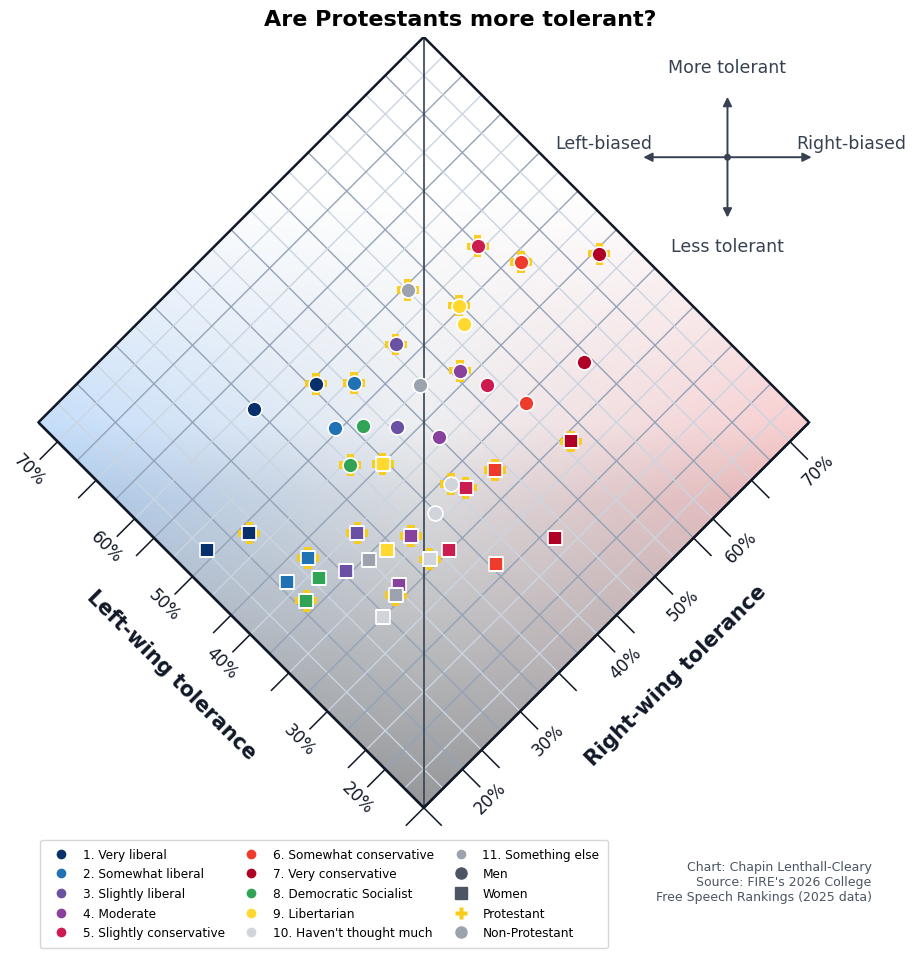

Saved: /Users/chapin.lenthall-cleary/diamond_scatter_left_vs_right_avg_by_ideology_gender_protestant.png


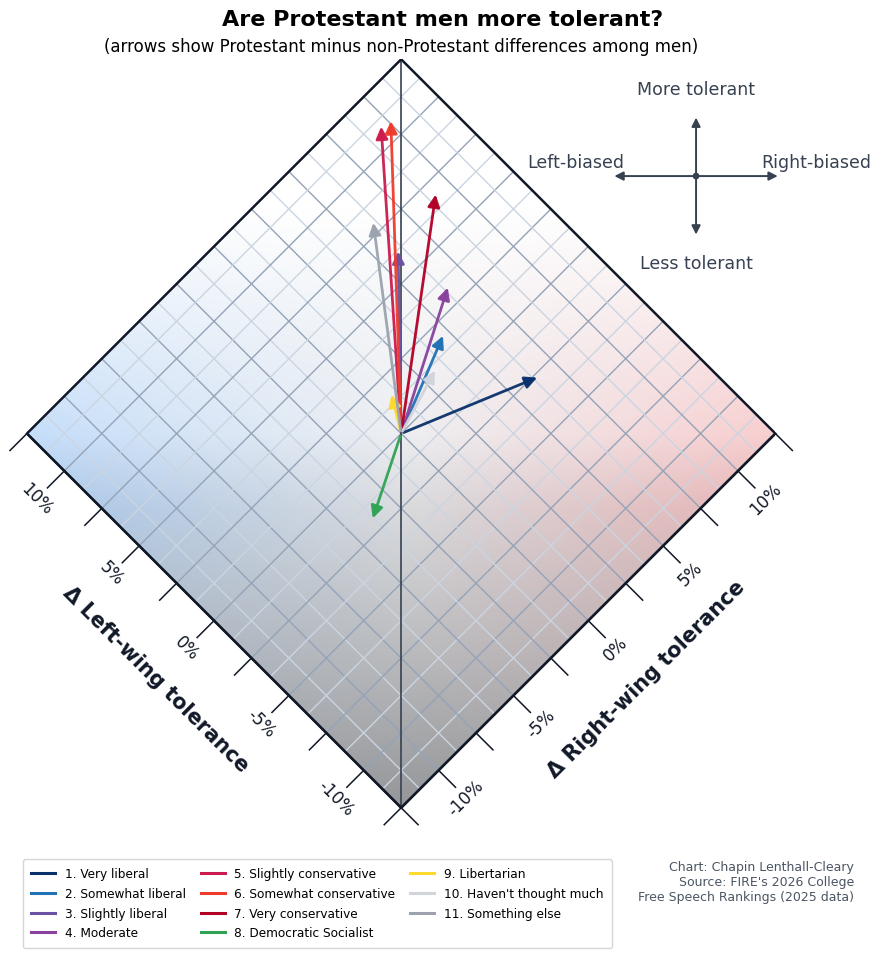

Saved: /Users/chapin.lenthall-cleary/diamond_vectors_prot_minus_nonprot_by_ideology_Men_2025.png

Men Protestant - Non-Protestant differences:


,ideo,Ideology,delta_left,delta_right,n_prot,n_nonprot
0,1,Very liberal,-2.8,6.6,77,2406
1,2,Somewhat liberal,1.9,4.8,167,3716
2,3,Slightly liberal,6.4,6.1,162,2502
3,4,Moderate,3.4,6.6,230,3911
4,5,Slightly conservative,11.2,9.8,202,1961
5,6,Somewhat conservative,11.0,10.3,347,2926
6,7,Very conservative,7.0,9.4,225,1423
7,8,Democratic Socialist,-2.0,-3.9,23,618
8,9,Libertarian,1.8,1.1,27,366
9,10,Haven't thought much,1.0,3.4,70,2301


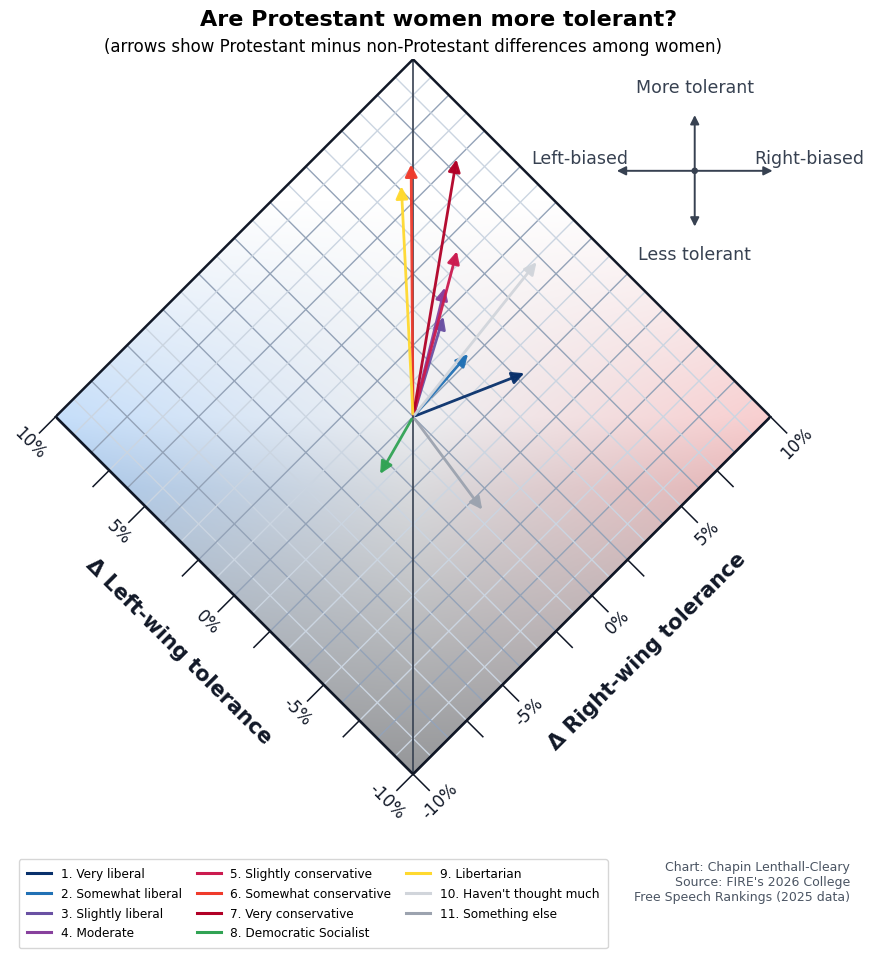

Saved: /Users/chapin.lenthall-cleary/diamond_vectors_prot_minus_nonprot_by_ideology_Women_2025.png

Women Protestant - Non-Protestant differences:


,ideo,Ideology,delta_left,delta_right,n_prot,n_nonprot
0,1,Very liberal,-1.9,4.4,304,7997
1,2,Somewhat liberal,0.2,3.4,496,10771
2,3,Slightly liberal,2.0,3.8,239,3990
3,4,Moderate,2.8,4.6,331,4924
4,5,Slightly conservative,3.5,6.0,204,1677
5,6,Somewhat conservative,7.2,7.1,374,2750
6,7,Very conservative,6.1,8.5,225,1563
7,8,Democratic Socialist,-0.7,-2.6,40,813
8,9,Libertarian,6.9,6.2,25,354
9,10,Haven't thought much,0.9,7.9,113,2780


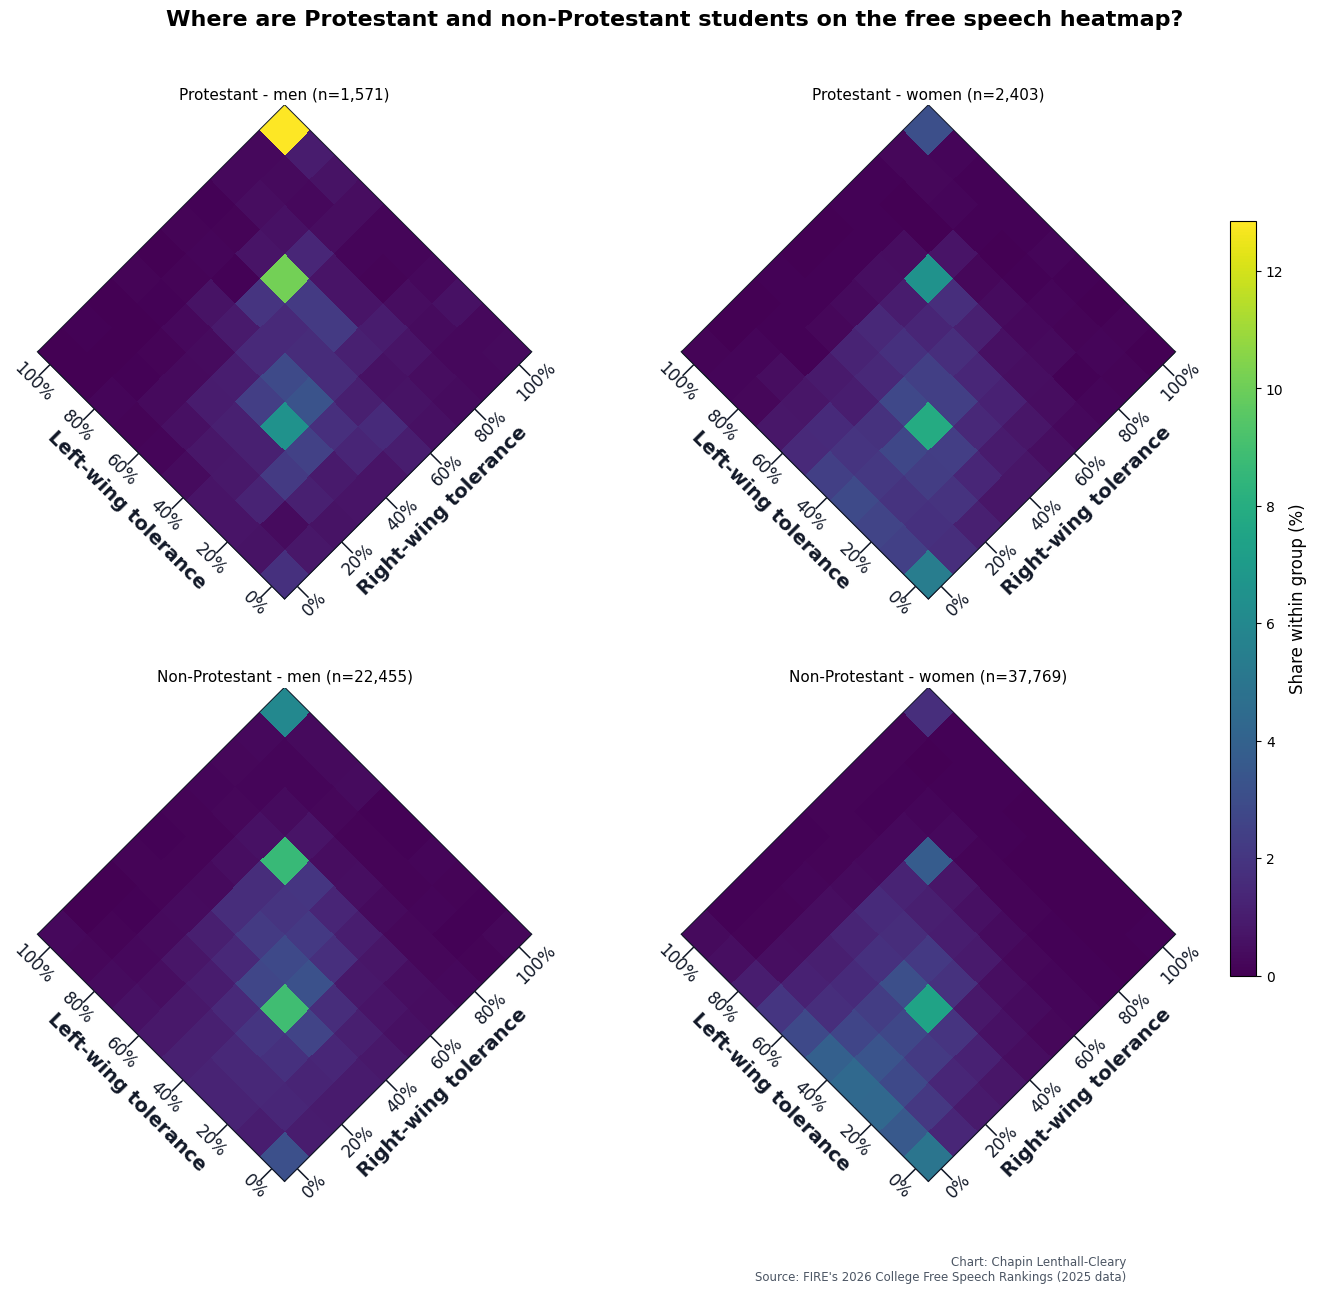

Saved: /Users/chapin.lenthall-cleary/diamond_heatmap_left_vs_right_by_gender_protestant.png

Plotted Protestant/non-Protestant group means:
 ideo              Ideology Gender Religion group  left_avg  right_avg     n
    1          Very liberal    Men Non-Protestant      57.9       32.2  2406
    1          Very liberal    Men     Protestant      55.1       38.8    77
    1          Very liberal  Women Non-Protestant      50.8       18.0  7997
    1          Very liberal  Women     Protestant      48.8       22.4   304
    2      Somewhat liberal    Men Non-Protestant      50.4       36.9  3716
    2      Somewhat liberal    Men     Protestant      52.3       41.7   167
    2      Somewhat liberal  Women Non-Protestant      42.3       21.6 10771
    2      Somewhat liberal  Women     Protestant      42.5       25.0   496
    3      Slightly liberal    Men Non-Protestant      45.7       41.7  2502
    3      Slightly liberal    Men     Protestant      52.1       47.8   162
    3      Sl

In [2]:
#!/usr/bin/env python3
"""
Diamond versions of the Protestant-vs-non-Protestant ideology/gender scatter
and Protestant-minus-non-Protestant vector plots.

Outputs:
  diamond_scatter_left_vs_right_avg_by_ideology_gender_protestant.png
  diamond_vectors_prot_minus_nonprot_by_ideology_Men_2025.png
  diamond_vectors_prot_minus_nonprot_by_ideology_Women_2025.png
  diamond_heatmap_left_vs_right_by_gender_protestant.png
  diamond_heatmap_left_vs_right_by_gender_protestant_annotated.png
  stacked_bar_ideology_by_religion_sorted_by_leaning.png
"""

from pathlib import Path
from typing import Callable, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from matplotlib.lines import Line2D
from matplotlib.patches import Circle, FancyArrowPatch, Polygon
from IPython.display import display

CSV_PATH = Path("cfsrALL_24_25.csv")
YEAR = 2025

OUT_SCATTER = Path("diamond_scatter_left_vs_right_avg_by_ideology_gender_protestant.png")
OUT_VECTOR_MEN = Path(f"diamond_vectors_prot_minus_nonprot_by_ideology_Men_{YEAR}.png")
OUT_VECTOR_WOMEN = Path(f"diamond_vectors_prot_minus_nonprot_by_ideology_Women_{YEAR}.png")
OUT_HEATMAP = Path("diamond_heatmap_left_vs_right_by_gender_protestant.png")
OUT_HEATMAP_ANNOTATED = Path("diamond_heatmap_left_vs_right_by_gender_protestant_annotated.png")

RIGHT_TRIAD = ["spk_abortion", "spk_trans", "spk_blm"]
LEFT_TRIAD = ["spk_cathped", "spk_policekkk", "spk_kidtrans"]
SPK_ALL = RIGHT_TRIAD + LEFT_TRIAD

IDEO_LABELS = {
    1: "Very liberal",
    2: "Somewhat liberal",
    3: "Slightly liberal",
    4: "Moderate",
    5: "Slightly conservative",
    6: "Somewhat conservative",
    7: "Very conservative",
    8: "Democratic Socialist",
    9: "Libertarian",
    10: "Haven't thought much",
    11: "Something else",
}
IDEO_COLORS = {
    1: "#08306b",
    2: "#2171b5",
    3: "#6a51a3",
    4: "#88419d",
    5: "#cb1b4f",
    6: "#ef3b2c",
    7: "#b10026",
    8: "#31a354",
    9: "#ffd92f",
    10: "#d1d5db",
    11: "#9ca3af",
}
IDEO_ORDER = list(IDEO_LABELS.keys())

# Same ideology weights as the talk/school-leaning notebook, inverted so conservative is positive.
IDEO_LEANING_WEIGHTS = {
    1: -3,
    2: -2,
    3: -1,
    4: 0,
    5: 1,
    6: 2,
    7: 3,
    8: -3,
    9: 0,
}

RELIGION_LABELS = {
    1: "Protestant",
    2: "Catholic",
    3: "Mormon",
    4: "Orthodox",
    5: "Jewish",
    6: "Muslim",
    7: "Atheist",
    8: "Agnostic",
    9: "Nothing in particular",
    10: "Just Christian",
    11: "Buddhist",
    12: "Hindu",
    13: "Other religion",
}

GENDER_LABELS = {1: "Men", 2: "Women"}
GENDER_MARKERS = {1: "o", 2: "s"}

FIG_W, FIG_H = 8.8 * 1.3, 8.6 * 1.3
BUFFER_PP_MIN = 1.5
BUFFER_FRAC = 0.06
SUPTITLE_Y = 0.925
TITLE_PAD = 6

CREDIT_TEXT = (
    "Chart: Chapin Lenthall-Cleary\n"
    "Source: FIRE's 2026 College\n"
    "Free Speech Rankings (2025 data)"
)
CREDIT_X, CREDIT_Y = 0.860, 0.125
CREDIT_COLOR = "#4b5563"

COMPASS_W = 0.40
COMPASS_H = 0.30
COMPASS_PAD = 0.006
COMPASS_SHIFT_RIGHT = 0.10

# Heatmap-specific larger label sizing.
HEATMAP_AXIS_LABEL_FONTSIZE = 14.0
HEATMAP_TICK_FONTSIZE = 12.0
HEATMAP_LABEL_PAD = 10.0
HEATMAP_TICK_LABEL_PAD = 1.8

P0 = np.array([50.0, 0.0])
VL = np.array([-50.0, 50.0])
VR = np.array([50.0, 50.0])


def scale_triad_to_pct(sum_vals: pd.Series, k: int = 3) -> pd.Series:
    return (sum_vals - k) / (3 * k) * 100.0


def build_ideo_like_code(df: pd.DataFrame) -> pd.Series:
    to_num = lambda c: pd.to_numeric(df.get(c), errors="coerce")
    fire, cp, raw = to_num("fire_ideo"), to_num("cp_ideo"), to_num("ideo")
    valid_fire = (fire >= 1) & (fire <= 11)
    valid_cp = (cp >= 1) & (cp <= 11)
    valid_raw = (raw >= 1) & (raw <= 11)
    ideo = np.where(valid_fire, fire, np.where(valid_cp, cp, np.where(valid_raw, raw, np.nan)))
    return pd.Series(ideo, index=df.index).astype("Int64")


def load_protestant_ideo_gender_stats(csv_path: Path, year: int) -> pd.DataFrame:
    usecols = ["datayear", "gender_bin", "religion", "ideo", *SPK_ALL]

    header = pd.read_csv(csv_path, nrows=0).columns
    for optional_col in ["fire_ideo", "cp_ideo"]:
        if optional_col in header:
            usecols.append(optional_col)

    df = pd.read_csv(csv_path, low_memory=False, usecols=lambda c: c in set(usecols))
    required = ["datayear", "gender_bin", "religion", "ideo", *SPK_ALL]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    for c in ["datayear", "gender_bin", "religion", *SPK_ALL]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df["ideo"] = build_ideo_like_code(df)

    df = df[
        (df["datayear"] == year)
        & (df["gender_bin"].isin([1, 2]))
        & (df["religion"].notna())
        & (df["ideo"].isin(range(1, 12)))
    ].copy()

    in_range = df[SPK_ALL].ge(1) & df[SPK_ALL].le(4)
    df = df[in_range.all(axis=1)].copy()

    if df.empty:
        raise SystemExit(
            "No rows remain after filtering to year, gender, ideology, religion, and valid speech items."
        )

    df["prot_bin"] = (df["religion"] == 1).astype(int)
    df["right_pct"] = scale_triad_to_pct(df[RIGHT_TRIAD].sum(axis=1), k=len(RIGHT_TRIAD))
    df["left_pct"] = scale_triad_to_pct(df[LEFT_TRIAD].sum(axis=1), k=len(LEFT_TRIAD))

    stats = (
        df.groupby(["ideo", "gender_bin", "prot_bin"], dropna=True)
        .agg(
            left_avg=("left_pct", "mean"),
            right_avg=("right_pct", "mean"),
            n=("left_pct", "size"),
        )
        .reset_index()
    )

    stats["ideo"] = stats["ideo"].astype(int)
    stats["gender_bin"] = stats["gender_bin"].astype(int)
    stats["prot_bin"] = stats["prot_bin"].astype(int)
    stats["Ideology"] = stats["ideo"].map(IDEO_LABELS)
    stats["Gender"] = stats["gender_bin"].map(GENDER_LABELS)
    stats["Religion group"] = np.where(stats["prot_bin"] == 1, "Protestant", "Non-Protestant")

    return stats.sort_values(["ideo", "gender_bin", "prot_bin"]).reset_index(drop=True)


def to_diamond_xy(left_vals, right_vals):
    left_vals = np.asarray(left_vals, dtype=float)
    right_vals = np.asarray(right_vals, dtype=float)
    s_left = left_vals / 100.0
    s_right = right_vals / 100.0
    xy = P0 + s_left[..., None] * VL + s_right[..., None] * VR
    return xy[..., 0], xy[..., 1]


def compute_zoom_range(left_vals: pd.Series, right_vals: pd.Series) -> tuple[float, float]:
    left = pd.to_numeric(left_vals, errors="coerce").dropna()
    right = pd.to_numeric(right_vals, errors="coerce").dropna()

    if left.empty or right.empty:
        return 0.0, 100.0

    minv = float(min(left.min(), right.min()))
    maxv = float(max(left.max(), right.max()))
    span = max(1e-6, maxv - minv)
    buffer = max(BUFFER_PP_MIN, BUFFER_FRAC * span)
    lo = max(0.0, minv - buffer)
    hi = min(100.0, maxv + buffer)

    if hi - lo < 5:
        mid = (hi + lo) / 2.0
        lo = max(0.0, mid - 2.5)
        hi = min(100.0, mid + 2.5)

    return lo, hi


def compute_delta_zoom_range(left_vals: pd.Series, right_vals: pd.Series) -> tuple[float, float]:
    vals = pd.concat(
        [
            pd.to_numeric(left_vals, errors="coerce"),
            pd.to_numeric(right_vals, errors="coerce"),
            pd.Series([0.0]),
        ],
        ignore_index=True,
    ).dropna()

    if vals.empty:
        return -5.0, 5.0

    max_abs = float(np.nanmax(np.abs(vals)))
    span = max(1e-6, 2 * max_abs)
    buffer = max(BUFFER_PP_MIN, BUFFER_FRAC * span)
    bound = max(2.5, max_abs + buffer)

    return -bound, bound


def normalize_to_zoom(vals, lo: float, hi: float):
    return np.clip((np.asarray(vals, dtype=float) - lo) / max(1e-9, hi - lo) * 100.0, 0, 100)


def zoom_axis_ticks(lo: float, hi: float):
    span = max(1e-9, hi - lo)
    label_step = 5.0 if span <= 35 else 10.0 if span <= 70 else 20.0
    tick_step = label_step / 2.0
    grid_step = 5.0

    first = np.ceil(lo / tick_step) * tick_step
    last = np.floor(hi / tick_step) * tick_step
    tick_values = np.arange(first, last + tick_step * 0.25, tick_step)
    tick_values = tick_values[(tick_values >= lo - 1e-9) & (tick_values <= hi + 1e-9)]

    if len(tick_values) < 2:
        tick_values = np.linspace(lo, hi, 5)

    raw_positions = (tick_values - lo) / span * 100.0
    snapped_positions = np.clip(np.round(raw_positions / grid_step) * grid_step, 0.0, 100.0)

    tick_positions = []
    labels_by_position: dict[float, str] = {}
    for pos, val in zip(snapped_positions, tick_values):
        pos = float(round(pos, 6))
        nearest = round(val / label_step) * label_step
        label = f"{int(round(nearest))}%" if abs(val - nearest) <= 1e-6 else ""
        if pos not in labels_by_position:
            tick_positions.append(pos)
            labels_by_position[pos] = label
        elif label and not labels_by_position[pos]:
            labels_by_position[pos] = label

    def tick_label_func(tick: float) -> str:
        return labels_by_position.get(float(round(tick, 6)), "")

    return tick_positions, tick_label_func


def add_2d_gradient_bg(ax, diamond_outline, *, nx=900, ny=900):
    x = np.linspace(0.0, 1.0, nx)
    y = np.linspace(0.0, 1.0, ny)
    X, Y = np.meshgrid(x, y)

    c_left = np.array(to_rgb("#93c5fd"))
    c_mid = np.array(to_rgb("#e5e7eb"))
    c_right = np.array(to_rgb("#fca5a5"))

    H = np.zeros((ny, nx, 3), dtype=float)
    u_left = np.clip(2 * X, 0, 1)
    u_right = np.clip(2 * (X - 0.5), 0, 1)

    for ch in range(3):
        H[..., ch] = np.where(
            X <= 0.5,
            (1 - u_left) * c_left[ch] + u_left * c_mid[ch],
            (1 - u_right) * c_mid[ch] + u_right * c_right[ch],
        )

    white = np.array(to_rgb("#ffffff"))
    gray = np.array(to_rgb("#e5e7eb"))
    t = np.clip(Y / 0.80, 0, 1)
    V = (1 - t)[..., None] * gray + t[..., None] * white
    bell = 1.0 - np.abs(2 * t - 1.0)
    alpha = 0.65 * bell
    img = (1 - alpha)[..., None] * V + alpha[..., None] * H

    shade_strength = np.clip((0.5 - Y) / 0.5, 0.0, 1.0)
    img *= 1.0 - 0.35 * shade_strength[..., None]
    img = np.clip(img, 0.0, 1.0)
    img[Y >= 0.85] = white

    im = ax.imshow(
        img,
        origin="lower",
        extent=[0, 100, 0, 100],
        interpolation="bilinear",
        zorder=-10,
    )
    im.set_clip_path(diamond_outline)


def add_compass(
    ax,
    *,
    width=COMPASS_W,
    height=COMPASS_H,
    pad=COMPASS_PAD,
    shift_right=COMPASS_SHIFT_RIGHT,
):
    cx = 1 - pad - width / 2 + shift_right
    cy = 1 - pad - height / 2
    hx, hy = width / 2.0, height / 2.0
    m = min(width, height) * 0.06
    color = "#374151"

    def r_max(theta):
        ct, st = abs(np.cos(theta)), abs(np.sin(theta))
        return min((hx - m) / max(ct, 1e-9), (hy - m) / max(st, 1e-9))

    for angle_deg, label in [
        (90, "More tolerant"),
        (180, "Left-biased"),
        (0, "Right-biased"),
        (270, "Less tolerant"),
    ]:
        th = np.deg2rad(angle_deg)
        rmax = r_max(th)
        r_arrow = rmax * 0.62
        r_label = rmax * 0.88

        arr = FancyArrowPatch(
            (cx, cy),
            (cx + r_arrow * np.cos(th), cy + r_arrow * np.sin(th)),
            transform=ax.transAxes,
            arrowstyle="-|>",
            mutation_scale=13,
            linewidth=1.4,
            color=color,
            zorder=21,
        )
        arr.set_clip_on(False)
        ax.add_patch(arr)

        y_offset = 0.018 if label in {"Left-biased", "Right-biased"} else 0.0
        txt = ax.text(
            cx + r_label * np.cos(th),
            cy + r_label * np.sin(th) + y_offset,
            label,
            transform=ax.transAxes,
            ha="center",
            va="center",
            fontsize=12.5,
            color=color,
            zorder=22,
        )
        txt.set_clip_on(False)

    center = Circle(
        (cx, cy),
        radius=min(width, height) * 0.012,
        transform=ax.transAxes,
        color=color,
        zorder=22,
    )
    center.set_clip_on(False)
    ax.add_patch(center)


def draw_edge_axis(
    ax,
    p0,
    p1,
    *,
    label,
    tick_vals=range(0, 101, 10),
    tick_len=3.2,
    label_pad=11.0,
    tick_label_pad=2.0,
    label_fontsize=15,
    tick_fontsize=12,
    color="#111827",
    increasing_from="start",
    tick_label_func: Optional[Callable[[int], str]] = None,
):
    p0 = np.asarray(p0, float)
    p1 = np.asarray(p1, float)
    v = p1 - p0
    length = float(np.hypot(v[0], v[1]))

    if length == 0:
        return

    u = v / length
    n_cw = np.array([u[1], -u[0]])
    n_ccw = np.array([-u[1], u[0]])
    n = n_cw if n_cw[1] < n_ccw[1] else n_ccw

    ax.plot(
        [p0[0], p1[0]],
        [p0[1], p1[1]],
        color=color,
        linewidth=1.6,
        zorder=4,
        clip_on=False,
    )

    edge_angle_deg = np.degrees(np.arctan2(v[1], v[0]))

    for tick in tick_vals:
        s = tick / 100.0
        pt = (p1 - u * (s * length)) if increasing_from == "end" else (p0 + u * (s * length))
        p_tick_end = pt + n * tick_len

        ax.plot(
            [pt[0], p_tick_end[0]],
            [pt[1], p_tick_end[1]],
            color=color,
            linewidth=1.1,
            zorder=4,
            clip_on=False,
        )

        p_text = pt + n * (tick_len + tick_label_pad)
        ax.text(
            p_text[0],
            p_text[1],
            tick_label_func(tick) if tick_label_func else f"{tick}%",
            ha="center",
            va="center",
            fontsize=tick_fontsize,
            color=color,
            rotation=edge_angle_deg,
            rotation_mode="anchor",
            zorder=5,
            clip_on=False,
        )

    mid = (p0 + p1) / 2.0
    p_label = mid + n * label_pad

    ax.text(
        p_label[0],
        p_label[1],
        label,
        ha="center",
        va="center",
        fontsize=label_fontsize,
        color=color,
        fontweight="bold",
        rotation=edge_angle_deg,
        rotation_mode="anchor",
        zorder=5,
        clip_on=False,
    )


def setup_diamond_axes(
    ax,
    lo: float,
    hi: float,
    *,
    left_label: str = "Left-wing tolerance",
    right_label: str = "Right-wing tolerance",
):
    diamond_xy = np.array([[50, 100], [100, 50], [50, 0], [0, 50]], dtype=float)
    diamond_outline = Polygon(
        diamond_xy,
        closed=True,
        facecolor="none",
        edgecolor="#111827",
        linewidth=1.8,
        zorder=3,
        joinstyle="miter",
    )
    ax.add_patch(diamond_outline)
    add_2d_gradient_bg(ax, diamond_outline)

    grid_artists = []
    for v in range(0, 101, 5):
        color = "#94a3b8" if (v // 5) % 2 == 0 else "#cbd5e1"

        x1, y1 = to_diamond_xy(v, 0)
        x2, y2 = to_diamond_xy(v, 100)
        line1, = ax.plot([x1, x2], [y1, y2], color=color, linewidth=1.0, zorder=0)

        x3, y3 = to_diamond_xy(0, v)
        x4, y4 = to_diamond_xy(100, v)
        line2, = ax.plot([x3, x4], [y3, y4], color=color, linewidth=1.0, zorder=0)

        grid_artists.extend([line1, line2])

    x0, y0 = to_diamond_xy(0, 0)
    xT, yT = to_diamond_xy(100, 100)
    parity_line, = ax.plot(
        [x0, xT],
        [y0, yT],
        color="#374151",
        linewidth=1.2,
        alpha=1.0,
        zorder=2,
    )

    for artist in [*grid_artists, parity_line]:
        artist.set_clip_path(diamond_outline)

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.set_aspect("equal", adjustable="box")

    add_compass(ax)

    tick_vals, tick_label_func = zoom_axis_ticks(lo, hi)

    draw_edge_axis(
        ax,
        (0, 50),
        (50, 0),
        label=left_label,
        tick_vals=tick_vals,
        increasing_from="end",
        tick_label_func=tick_label_func,
    )
    draw_edge_axis(
        ax,
        (50, 0),
        (100, 50),
        label=right_label,
        tick_vals=tick_vals,
        tick_label_func=tick_label_func,
    )

    return diamond_outline


def add_common_titles_and_credit(fig, ax, title: str | None, suptitle: str = "Are Protestants more tolerant?"):
    if title:
        ax.set_title(title, pad=TITLE_PAD)
    fig.suptitle(suptitle, fontsize=16, fontweight="bold", y=SUPTITLE_Y)
    fig.text(
        CREDIT_X,
        CREDIT_Y,
        CREDIT_TEXT,
        ha="right",
        va="bottom",
        fontsize=9,
        color=CREDIT_COLOR,
    )


def add_ideology_legend(
    fig,
    *,
    include_gender=True,
    include_protestant=True,
    anchor=(0.128, 0.080),
    use_line_handles=False,
):
    if use_line_handles:
        ideology_handles = [
            Line2D([0], [0], color=IDEO_COLORS[i], lw=2.2, label=f"{i}. {IDEO_LABELS[i]}")
            for i in range(1, 12)
        ]
    else:
        ideology_handles = [
            Line2D(
                [0],
                [0],
                marker="o",
                linestyle="",
                markerfacecolor=IDEO_COLORS[i],
                markeredgecolor="white",
                markersize=8,
                label=f"{i}. {IDEO_LABELS[i]}",
            )
            for i in range(1, 12)
        ]

    handles = ideology_handles
    ncol = 3

    if include_gender:
        handles = handles + [
            Line2D([0], [0], marker="o", linestyle="", color="#4b5563", markersize=8, label="Men"),
            Line2D([0], [0], marker="s", linestyle="", color="#4b5563", markersize=8, label="Women"),
        ]

    if include_protestant:
        handles = handles + [
            Line2D(
                [0],
                [0],
                marker="P",
                linestyle="",
                markerfacecolor="#facc15",
                markeredgecolor="none",
                color="none",
                markersize=9,
                label="Protestant",
            ),
            Line2D(
                [0],
                [0],
                marker="o",
                linestyle="",
                color="#9ca3af",
                markersize=8,
                label="Non-Protestant",
            ),
        ]

    legend = fig.legend(
        handles=handles,
        loc="lower left",
        bbox_to_anchor=anchor,
        frameon=True,
        fontsize=8.7,
        ncol=ncol,
        borderpad=0.7,
        labelspacing=0.55,
        columnspacing=1.2,
    )
    legend._legend_box.align = "left"


def plot_protestant_ideo_gender_scatter_diamond(stats: pd.DataFrame, out_path: Path):
    lo, hi = compute_zoom_range(stats["left_avg"], stats["right_avg"])
    left_norm = normalize_to_zoom(stats["left_avg"], lo, hi)
    right_norm = normalize_to_zoom(stats["right_avg"], lo, hi)
    xd, yd = to_diamond_xy(left_norm, right_norm)

    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
    diamond_outline = setup_diamond_axes(ax, lo, hi)

    artists = []
    for idx, row in stats.reset_index(drop=True).iterrows():
        x, y = float(xd[idx]), float(yd[idx])
        ideology = int(row["ideo"])
        gender = int(row["gender_bin"])
        is_prot = int(row["prot_bin"]) == 1
        color = IDEO_COLORS.get(ideology, "#9ca3af")
        marker = GENDER_MARKERS.get(gender, "o")

        if is_prot:
            bg = ax.scatter(
                [x],
                [y],
                s=250,
                marker="P",
                facecolor="#facc15",
                edgecolors="none",
                linewidths=0,
                alpha=0.95,
                zorder=5,
            )
            artists.append(bg)

        point = ax.scatter(
            [x],
            [y],
            s=115,
            marker=marker,
            c=[color],
            edgecolor="white",
            linewidth=1.2,
            zorder=6,
        )
        artists.append(point)

    for artist in artists:
        if hasattr(artist, "set_clip_path"):
            artist.set_clip_path(diamond_outline)

    add_ideology_legend(fig, include_gender=True, include_protestant=True)
    add_common_titles_and_credit(fig, ax, None)

    fig.tight_layout(rect=[0.02, 0.18, 0.98, 0.945])
    fig.savefig(out_path, dpi=220, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_path.resolve()}")


def paired_points_for_gender(stats: pd.DataFrame, gender_code: int) -> pd.DataFrame:
    s = stats[stats["gender_bin"] == gender_code].copy()

    left = s.pivot(index="ideo", columns="prot_bin", values="left_avg")
    right = s.pivot(index="ideo", columns="prot_bin", values="right_avg")
    n = s.pivot(index="ideo", columns="prot_bin", values="n")

    out = pd.DataFrame(
        {
            "left_nonprot": left.get(0),
            "right_nonprot": right.get(0),
            "left_prot": left.get(1),
            "right_prot": right.get(1),
            "n_nonprot": n.get(0),
            "n_prot": n.get(1),
        }
    ).dropna().reset_index()

    out["ideo"] = out["ideo"].astype(int)
    out["Ideology"] = out["ideo"].map(IDEO_LABELS)
    out["delta_left"] = out["left_prot"] - out["left_nonprot"]
    out["delta_right"] = out["right_prot"] - out["right_nonprot"]

    return out.sort_values("ideo").reset_index(drop=True)


def plot_protestant_vectors_diamond(stats: pd.DataFrame, gender_code: int, out_path: Path):
    gender_label = GENDER_LABELS[gender_code]
    paired = paired_points_for_gender(stats, gender_code)

    if paired.empty:
        raise SystemExit(f"No paired Protestant/non-Protestant points for {gender_label}.")

    lo, hi = compute_delta_zoom_range(paired["delta_left"], paired["delta_right"])

    origin_norm = float(normalize_to_zoom([0.0], lo, hi)[0])
    origin_x, origin_y = to_diamond_xy([origin_norm], [origin_norm])

    end_left = normalize_to_zoom(paired["delta_left"], lo, hi)
    end_right = normalize_to_zoom(paired["delta_right"], lo, hi)
    x1, y1 = to_diamond_xy(end_left, end_right)

    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
    diamond_outline = setup_diamond_axes(
        ax,
        lo,
        hi,
        left_label="Δ Left-wing tolerance",
        right_label="Δ Right-wing tolerance",
    )

    for idx, row in paired.iterrows():
        ideology = int(row["ideo"])
        color = IDEO_COLORS.get(ideology, "#9ca3af")

        arrow = FancyArrowPatch(
            (float(origin_x[0]), float(origin_y[0])),
            (float(x1[idx]), float(y1[idx])),
            arrowstyle="-|>",
            mutation_scale=18,
            linewidth=2.0,
            color=color,
            alpha=0.95,
            zorder=8,
        )
        arrow.set_clip_path(diamond_outline)
        ax.add_patch(arrow)

    add_ideology_legend(
        fig,
        include_gender=False,
        include_protestant=False,
        use_line_handles=True,
    )
    add_common_titles_and_credit(
        fig,
        ax,
        f"(arrows show Protestant minus non-Protestant differences among {gender_label.lower()})",
        f"Are Protestant {gender_label.lower()} more tolerant?",
    )

    fig.tight_layout(rect=[0.02, 0.18, 0.98, 0.945])
    fig.savefig(out_path, dpi=220, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_path.resolve()}")

    print(f"\n{gender_label} Protestant - Non-Protestant differences:")
    display_cols = ["ideo", "Ideology", "delta_left", "delta_right", "n_prot", "n_nonprot"]
    display(paired[display_cols].round({"delta_left": 1, "delta_right": 1}))


def score_bin_edges() -> np.ndarray:
    score_values = scale_triad_to_pct(
        pd.Series(np.arange(len(RIGHT_TRIAD), 4 * len(RIGHT_TRIAD) + 1)),
        k=len(RIGHT_TRIAD),
    ).to_numpy(dtype=float)

    step = float(np.diff(score_values).mean())
    mids = (score_values[:-1] + score_values[1:]) / 2.0

    return np.r_[score_values[0] - step / 2.0, mids, score_values[-1] + step / 2.0]


def load_protestant_heatmap_data(csv_path: Path, year: int) -> pd.DataFrame:
    usecols = ["datayear", "gender_bin", "religion", *SPK_ALL]
    df = pd.read_csv(csv_path, low_memory=False, usecols=lambda c: c in set(usecols))

    missing = [c for c in usecols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    for c in usecols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df = df[
        (df["datayear"] == year)
        & (df["gender_bin"].isin([1, 2]))
        & (df["religion"].isin(range(1, 14)))
    ].copy()

    in_range = df[SPK_ALL].ge(1) & df[SPK_ALL].le(4)
    df = df[in_range.all(axis=1)].copy()

    if df.empty:
        raise SystemExit("No rows remain for Protestant/non-Protestant heatmaps after filtering.")

    df["gender_bin"] = df["gender_bin"].astype(int)
    df["prot_bin"] = (df["religion"] == 1).astype(int)
    df["right_pct"] = scale_triad_to_pct(df[RIGHT_TRIAD].sum(axis=1), k=len(RIGHT_TRIAD))
    df["left_pct"] = scale_triad_to_pct(df[LEFT_TRIAD].sum(axis=1), k=len(LEFT_TRIAD))

    return df


def setup_heatmap_diamond_axes(ax, edge_min: float, edge_max: float):
    diamond_xy = np.array([[50, 100], [100, 50], [50, 0], [0, 50]], dtype=float)
    diamond_outline = Polygon(
        diamond_xy,
        closed=True,
        facecolor="none",
        edgecolor="#111827",
        linewidth=1.4,
        zorder=3,
        joinstyle="miter",
    )
    ax.add_patch(diamond_outline)
    add_2d_gradient_bg(ax, diamond_outline, nx=450, ny=450)

    grid_artists = []
    score_ticks = np.arange(0, 101, 10)
    tick_vals = ((score_ticks - edge_min) / (edge_max - edge_min) * 100.0).tolist()

    for tick in tick_vals:
        color = "#94a3b8" if round(tick) % 20 == 0 else "#cbd5e1"

        x1, y1 = to_diamond_xy(tick, 0)
        x2, y2 = to_diamond_xy(tick, 100)
        line1, = ax.plot([x1, x2], [y1, y2], color=color, linewidth=0.75, zorder=0)

        x3, y3 = to_diamond_xy(0, tick)
        x4, y4 = to_diamond_xy(100, tick)
        line2, = ax.plot([x3, x4], [y3, y4], color=color, linewidth=0.75, zorder=0)

        grid_artists.extend([line1, line2])

    zero_line_pos = (0.0 - edge_min) / (edge_max - edge_min) * 100.0
    hundred_line_pos = (100.0 - edge_min) / (edge_max - edge_min) * 100.0

    x0, y0 = to_diamond_xy(zero_line_pos, zero_line_pos)
    xT, yT = to_diamond_xy(hundred_line_pos, hundred_line_pos)

    parity_line, = ax.plot(
        [x0, xT],
        [y0, yT],
        color="#374151",
        linewidth=1.0,
        alpha=1.0,
        zorder=2,
    )

    for artist in [*grid_artists, parity_line]:
        artist.set_clip_path(diamond_outline)

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.set_aspect("equal", adjustable="box")

    def tick_label_func(tick: float) -> str:
        score = edge_min + (tick / 100.0) * (edge_max - edge_min)
        return f"{int(round(score))}%"

    label_ticks = ((np.arange(0, 101, 20) - edge_min) / (edge_max - edge_min) * 100.0).tolist()

    draw_edge_axis(
        ax,
        (0, 50),
        (50, 0),
        label="Left-wing tolerance",
        tick_vals=label_ticks,
        tick_len=3.2,
        label_pad=HEATMAP_LABEL_PAD,
        tick_label_pad=HEATMAP_TICK_LABEL_PAD,
        label_fontsize=HEATMAP_AXIS_LABEL_FONTSIZE,
        tick_fontsize=HEATMAP_TICK_FONTSIZE,
        increasing_from="end",
        tick_label_func=tick_label_func,
    )

    draw_edge_axis(
        ax,
        (50, 0),
        (100, 50),
        label="Right-wing tolerance",
        tick_vals=label_ticks,
        tick_len=3.2,
        label_pad=HEATMAP_LABEL_PAD,
        tick_label_pad=HEATMAP_TICK_LABEL_PAD,
        label_fontsize=HEATMAP_AXIS_LABEL_FONTSIZE,
        tick_fontsize=HEATMAP_TICK_FONTSIZE,
        tick_label_func=tick_label_func,
    )

    return diamond_outline


def plot_protestant_gender_heatmaps_diamond(
    df: pd.DataFrame,
    out_path: Path,
    *,
    annotate_cells: bool = False,
):
    edges = score_bin_edges()
    edge_min, edge_max = float(edges[0]), float(edges[-1])
    norm_edges = (edges - edge_min) / (edge_max - edge_min) * 100.0

    mesh_l, mesh_r = np.meshgrid(norm_edges, norm_edges)
    mesh_x, mesh_y = to_diamond_xy(mesh_l, mesh_r)

    grids = {}
    vmax = 0.0

    for row_idx, prot_bin in enumerate([1, 0]):
        for col_idx, gender_code in enumerate([1, 2]):
            sub = df[(df["prot_bin"] == prot_bin) & (df["gender_bin"] == gender_code)]

            if sub.empty:
                pct = np.zeros((len(edges) - 1, len(edges) - 1), dtype=float)
                n = 0
            else:
                hist, _, _ = np.histogram2d(
                    sub["left_pct"],
                    sub["right_pct"],
                    bins=[edges, edges],
                )
                pct = hist / len(sub) * 100.0
                n = int(len(sub))

            grids[(row_idx, col_idx)] = (pct, n)
            vmax = max(vmax, float(np.nanmax(pct)))

    fig = plt.figure(figsize=(14.8, 12.8))

    # Manual axes avoid wide blank columns from aspect="equal" subplot boxes.
    panel_w, panel_h = 0.333, 0.385
    x_left, x_right = 0.070, 0.505
    y_top, y_bottom = 0.505, 0.050

    axes = np.array(
        [
            [
                fig.add_axes([x_left, y_top, panel_w, panel_h]),
                fig.add_axes([x_right, y_top, panel_w, panel_h]),
            ],
            [
                fig.add_axes([x_left, y_bottom, panel_w, panel_h]),
                fig.add_axes([x_right, y_bottom, panel_w, panel_h]),
            ],
        ]
    )

    row_labels = {0: "Protestant", 1: "Non-Protestant"}
    meshes = []
    cmap = plt.get_cmap("viridis")

    for row_idx, prot_bin in enumerate([1, 0]):
        for col_idx, gender_code in enumerate([1, 2]):
            ax = axes[row_idx, col_idx]
            diamond_outline = setup_heatmap_diamond_axes(ax, edge_min, edge_max)
            pct, n = grids[(row_idx, col_idx)]

            # No white cell borders. antialiased=False helps prevent faint seams in PNG export.
            mesh = ax.pcolormesh(
                mesh_x,
                mesh_y,
                pct.T,
                cmap=cmap,
                shading="flat",
                vmin=0,
                vmax=max(1e-9, vmax),
                edgecolors="none",
                linewidth=0,
                antialiased=False,
                zorder=4,
            )
            mesh.set_clip_path(diamond_outline)
            meshes.append(mesh)

            if annotate_cells:
                for ix in range(pct.shape[0]):
                    for iy in range(pct.shape[1]):
                        val = float(pct[ix, iy])

                        if val <= 0:
                            continue

                        center_l = (norm_edges[ix] + norm_edges[ix + 1]) / 2.0
                        center_r = (norm_edges[iy] + norm_edges[iy + 1]) / 2.0
                        x, y = to_diamond_xy(center_l, center_r)

                        text_color = "white" if val >= 0.45 * max(1e-9, vmax) else "#111827"

                        ax.text(
                            float(x),
                            float(y),
                            f"{val:.1f}%",
                            ha="center",
                            va="center",
                            fontsize=6.4,
                            color=text_color,
                            fontweight="bold" if val >= 0.45 * max(1e-9, vmax) else "normal",
                            zorder=7,
                            clip_on=True,
                        )

            ax.set_title(
                f"{row_labels[row_idx]} - {GENDER_LABELS[gender_code].lower()} (n={n:,})",
                fontsize=11,
                pad=5,
            )

    cax = fig.add_axes([0.875, 0.210, 0.018, 0.590])
    cbar = fig.colorbar(meshes[0], cax=cax)
    cbar.set_label("Share within group (%)", fontsize=12)
    cbar.ax.tick_params(labelsize=10)

    fig.suptitle(
        "Where are Protestant and non-Protestant students on the free speech heatmap?",
        fontsize=16,
        fontweight="bold",
        y=0.965,
    )

    heatmap_credit_text = (
        "Chart: Chapin Lenthall-Cleary\n"
        "Source: FIRE's 2026 College Free Speech Rankings (2025 data)"
    )
    fig.text(
        0.805,
        -0.030,
        heatmap_credit_text,
        ha="right",
        va="bottom",
        fontsize=8.5,
        color=CREDIT_COLOR,
    )

    fig.savefig(out_path, dpi=220, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_path.resolve()}")



stats = load_protestant_ideo_gender_stats(CSV_PATH, YEAR)

plot_protestant_ideo_gender_scatter_diamond(stats, OUT_SCATTER)
plot_protestant_vectors_diamond(stats, 1, OUT_VECTOR_MEN)
plot_protestant_vectors_diamond(stats, 2, OUT_VECTOR_WOMEN)

heatmap_df = load_protestant_heatmap_data(CSV_PATH, YEAR)
plot_protestant_gender_heatmaps_diamond(heatmap_df, OUT_HEATMAP, annotate_cells=False)

print("\nPlotted Protestant/non-Protestant group means:")
print(
    stats.assign(
        left_avg=lambda d: d["left_avg"].round(1),
        right_avg=lambda d: d["right_avg"].round(1),
    )[["ideo", "Ideology", "Gender", "Religion group", "left_avg", "right_avg", "n"]]
    .to_string(index=False)
)


Religion counts, 2025 (Other combines religion codes 13 and 99):


,Religion,N,Attendance_N,Percent
0,Protestant,4097,4077,6.0
1,Catholic,12637,12593,18.4
2,Mormon,553,549,0.8
3,Orthodox,1067,1059,1.6
4,Jewish,2561,2556,3.7
5,Muslim,2269,2258,3.3
6,Atheist,7863,7842,11.5
7,Agnostic,9689,9653,14.1
8,Nothing in particular,8981,8947,13.1
9,Christian,13291,13248,19.4


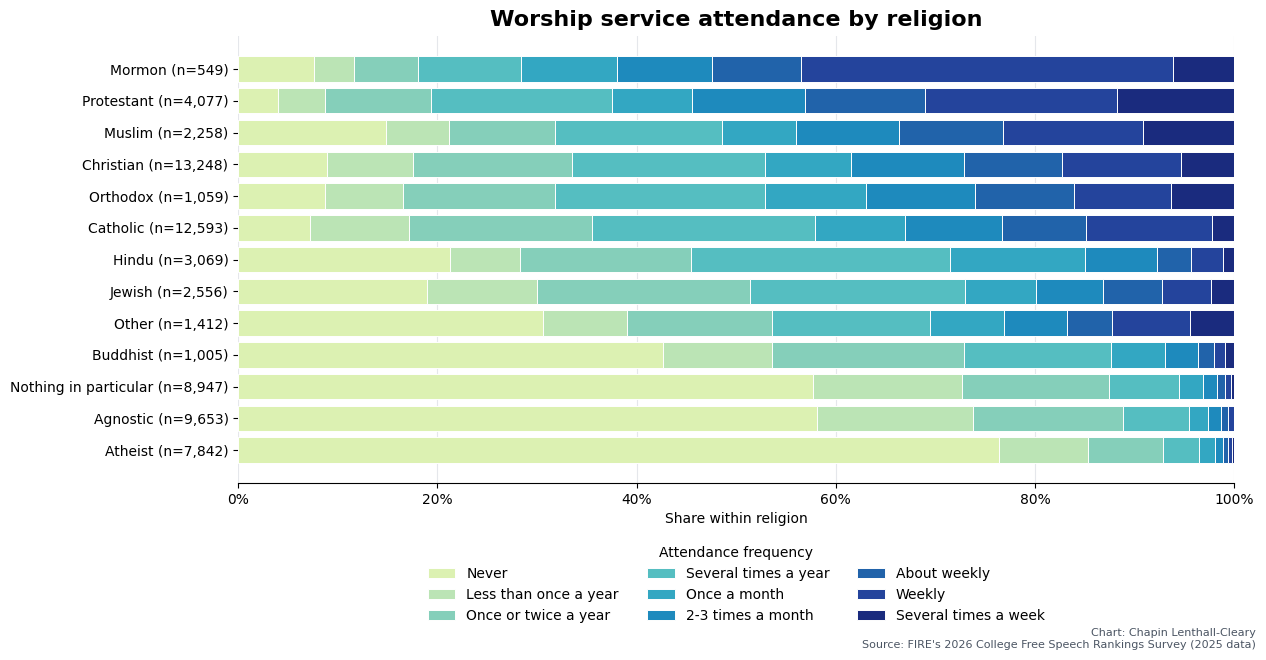

Saved: /Users/chapin.lenthall-cleary/stacked_bar_religious_attendance_by_religion.png


In [3]:
#!/usr/bin/env python3
"""
Counts of students in each religion, plus attendance charts by religion.

Notes:
- Uses cfsrALL_24_25.csv filtered to 2025.
- Bins religion code 99 and religion code 13 together as Other.
- Attendance charts use valid attendance codes 1..9.
- Weighted-average attendance uses the survey weight column.

Outputs:
  stacked_bar_religious_attendance_by_religion.png
"""

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display

CSV_PATH = Path("cfsrALL_24_25.csv")
YEAR = 2025
WEIGHT_COL = "weight"
OUT_STACKED = Path("stacked_bar_religious_attendance_by_religion.png")
OUT_AVG = Path("bar_religious_attendance_weighted_average_by_religion.png")

RELIGION_LABELS = {
    1: "Protestant",
    2: "Catholic",
    3: "Mormon",
    4: "Orthodox",
    5: "Jewish",
    6: "Muslim",
    7: "Atheist",
    8: "Agnostic",
    9: "Nothing in particular",
    10: "Christian",
    11: "Buddhist",
    12: "Hindu",
    13: "Other",
}
RELIGION_ORDER = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]

ATTENDANCE_LABELS = {
    1: "Never",
    2: "Less than once a year",
    3: "Once or twice a year",
    4: "Several times a year",
    5: "Once a month",
    6: "2-3 times a month",
    7: "About weekly",
    8: "Weekly",
    9: "Several times a week",
}
ATTENDANCE_ORDER = list(ATTENDANCE_LABELS)


def load_religion_attendance(csv_path: Path, year: int) -> pd.DataFrame:
    df = pd.read_csv(
        csv_path,
        low_memory=False,
        usecols=["datayear", "religion", "attendreligserv", WEIGHT_COL],
    )
    for col in ["datayear", "religion", "attendreligserv", WEIGHT_COL]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df[df["datayear"] == year].copy()
    # In cfsrALL_24_25, 2025 open-ended Other responses are coded as religion == 99.
    df.loc[df["religion"].isin([13, 99]), "religion_binned"] = 13
    df.loc[~df["religion"].isin([13, 99]), "religion_binned"] = df.loc[
        ~df["religion"].isin([13, 99]), "religion"
    ]
    df = df[df["religion_binned"].isin(RELIGION_ORDER)].copy()
    df["religion_binned"] = df["religion_binned"].astype(int)
    df["Religion"] = df["religion_binned"].map(RELIGION_LABELS)
    return df


def religion_counts(df: pd.DataFrame) -> pd.DataFrame:
    counts = (
        df.groupby(["religion_binned", "Religion"], observed=True)
        .agg(N=("Religion", "size"), Attendance_N=("attendreligserv", lambda s: s.isin(ATTENDANCE_ORDER).sum()))
        .reset_index()
    )
    counts["Percent"] = counts["N"] / counts["N"].sum() * 100
    counts["Percent"] = counts["Percent"].round(1)
    return counts.sort_values("religion_binned").drop(columns="religion_binned").reset_index(drop=True)


def attendance_distribution(df: pd.DataFrame) -> pd.DataFrame:
    valid = df[df["attendreligserv"].isin(ATTENDANCE_ORDER)].copy()
    valid["attendreligserv"] = valid["attendreligserv"].astype(int)
    counts = (
        valid.groupby(["religion_binned", "Religion", "attendreligserv"], observed=True)
        .size()
        .rename("N")
        .reset_index()
    )
    wide = (
        counts.pivot_table(
            index=["religion_binned", "Religion"],
            columns="attendreligserv",
            values="N",
            fill_value=0,
            aggfunc="sum",
        )
        .reindex(columns=ATTENDANCE_ORDER, fill_value=0)
        .reset_index()
        .sort_values("religion_binned")
    )
    denom = wide[ATTENDANCE_ORDER].sum(axis=1).replace(0, np.nan)
    pct = wide.copy()
    pct[ATTENDANCE_ORDER] = wide[ATTENDANCE_ORDER].div(denom, axis=0) * 100
    pct["Attendance_N"] = denom.astype("Int64")
    return pct


def weighted_average_attendance(df: pd.DataFrame) -> pd.DataFrame:
    valid = df[
        df["attendreligserv"].isin(ATTENDANCE_ORDER)
        & df[WEIGHT_COL].notna()
        & (df[WEIGHT_COL] > 0)
    ].copy()
    valid["attendreligserv"] = valid["attendreligserv"].astype(float)

    rows = []
    for (code, religion), g in valid.groupby(["religion_binned", "Religion"], observed=True):
        avg = np.average(g["attendreligserv"], weights=g[WEIGHT_COL])
        rows.append({
            "religion_binned": code,
            "Religion": religion,
            "Weighted average attendance": avg,
            "Attendance_N": len(g),
            "Weighted_N": g[WEIGHT_COL].sum(),
        })
    out = pd.DataFrame(rows)
    out["Weighted average attendance"] = out["Weighted average attendance"].round(2)
    out["Weighted_N"] = out["Weighted_N"].round(1)
    return out.sort_values("Weighted average attendance", ascending=True).reset_index(drop=True)


def plot_attendance_by_religion(pct: pd.DataFrame, sort_order: pd.Series, out_path: Path):
    order = {code: i for i, code in enumerate(sort_order)}
    plot_df = pct.copy()
    plot_df["_sort"] = plot_df["religion_binned"].map(order)
    plot_df = plot_df.sort_values("_sort").drop(columns="_sort").reset_index(drop=True)
    y = np.arange(len(plot_df))

    fig, ax = plt.subplots(figsize=(13, 8.5))
    left = np.zeros(len(plot_df))
    colors = plt.cm.YlGnBu(np.linspace(0.18, 0.92, len(ATTENDANCE_ORDER)))

    for code, color in zip(ATTENDANCE_ORDER, colors):
        vals = plot_df[code].fillna(0).to_numpy(dtype=float)
        ax.barh(
            y,
            vals,
            left=left,
            label=ATTENDANCE_LABELS[code],
            color=color,
            edgecolor="white",
            linewidth=0.7,
        )
        left += vals

    labels = [f"{r} (n={n:,})" for r, n in zip(plot_df["Religion"], plot_df["Attendance_N"])]
    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.invert_yaxis()
    ax.set_xlim(0, 100)
    ax.xaxis.set_major_formatter(PercentFormatter(xmax=100))
    ax.set_xlabel("Share within religion")
    ax.grid(axis="x", color="#e5e7eb", linewidth=0.8)
    ax.set_axisbelow(True)
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)

    ax.legend(
        title="Attendance frequency",
        loc="lower center",
        bbox_to_anchor=(0.5, -0.34),
        ncol=3,
        frameon=False,
    )
    fig.tight_layout(rect=[0.02, 0.13, 1.0, 0.945])

    ax_pos = ax.get_position()
    fig.suptitle(
        "Worship service attendance by religion",
        x=ax_pos.x0 + ax_pos.width / 2,
        y=0.958,
        fontsize=16,
        fontweight="bold",
    )
    fig.text(
        0.99, 0.205,
        "Chart: Chapin Lenthall-Cleary\nSource: FIRE's 2026 College Free Speech Rankings Survey (2025 data)",
        ha="right", va="bottom", fontsize=8, color="#4b5563"
    )
    fig.savefig(out_path, dpi=220, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_path.resolve()}")


def plot_weighted_average_attendance(avg: pd.DataFrame, out_path: Path):
    plot_df = avg.sort_values("Weighted average attendance", ascending=True).copy()
    y = np.arange(len(plot_df))

    fig, ax = plt.subplots(figsize=(11, 7.5))
    bars = ax.barh(y, plot_df["Weighted average attendance"], color="#2a9d8f", edgecolor="white", linewidth=0.8)

    ax.set_yticks(y)
    ax.set_yticklabels([f"{r} (n={n:,})" for r, n in zip(plot_df["Religion"], plot_df["Attendance_N"])])
    ax.set_xlim(1, 9)
    ax.set_xlabel("Weighted average attendance score")
    ax.set_title(f"Average religious service attendance by religion, {YEAR}", fontsize=15, fontweight="bold")
    ax.set_xticks(ATTENDANCE_ORDER)
    ax.set_xticklabels([
        "Never", "< yearly", "1-2/year", "Several/year", "Monthly",
        "2-3/month", "About weekly", "Weekly", "Several/week"
    ], rotation=30, ha="right")
    ax.grid(axis="x", color="#e5e7eb", linewidth=0.8)
    ax.set_axisbelow(True)
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)

    for bar, value in zip(bars, plot_df["Weighted average attendance"]):
        ax.text(
            value + 0.05,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.2f}",
            va="center",
            ha="left",
            fontsize=9,
            color="#111827",
        )

    fig.text(
        0.99, 0.075,
        "Chart: Chapin Lenthall-Cleary\nSource: FIRE's 2026 College Free Speech Rankings Survey (2025 data)",
        ha="right", va="bottom", fontsize=8, color="#4b5563"
    )
    fig.tight_layout(rect=[0.02, 0.08, 1.0, 0.98])
    fig.savefig(out_path, dpi=220, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_path.resolve()}")



df = load_religion_attendance(CSV_PATH, YEAR)
counts = religion_counts(df)
attendance_pct = attendance_distribution(df)
avg_attendance = weighted_average_attendance(df)

print(f"Religion counts, {YEAR} (Other combines religion codes 13 and 99):")
display(counts)

stacked_sort_order = avg_attendance.sort_values("Weighted average attendance", ascending=False)["religion_binned"]
plot_attendance_by_religion(attendance_pct, stacked_sort_order, OUT_STACKED)
